# İklim Değişikliği, Afetler ve Göç İlişkisi — Keşifsel Veri Analizi (EDA)

**Grup görevi kapsamında hazırlanan EDA bölümü**

Bu notebook iki veri setini inceler:

1. **`iklim_afet_tablosu.xlsx`** — 48 Afrika ülkesi için 2001–2025 yılları arasında yıllık ortalama sıcaklık, yağış ve doğal afet göstergeleri
2. **`goc_tablosu.xlsx`** — UNHCR tarzı ikili (origin → asylum) uluslararası zorunlu göç/mülteci akış verisi (2001–2025)

**Amaç:** Bu iki veri setini birlikte inceleyerek iklim/afet göstergeleri ile göç hareketleri arasındaki olası ilişkileri, zaman içindeki eğilimleri ve ülke bazlı farklılıkları keşfetmek. Bu bir **modelleme** çalışması değildir — amaç veriyi tanımak, kalitesini değerlendirmek ve anlamlı örüntüleri ortaya çıkarmaktır.

> **Not:** Görev tanımında geçen bazı değişkenler (ör. *çatışma, nüfus, mülteci/sığınmacı ayrımı, makro_bölge, sıcaklık/yağış anomalisi*) elimizdeki gerçek dosyalarda bulunmamaktadır. Bu notebook, dosyalarda **gerçekten var olan** sütunlarla çalışır; bulunmayan değişkenler için varsayımsal sonuç üretilmemiştir. Bu durum Bölüm 1'de ayrıntılı olarak açıklanmaktadır.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

DATA_DIR = "data"
print("Kütüphaneler yüklendi.")


Kütüphaneler yüklendi.


## 1. Veri Setlerinin Tanınması

### 1.1 Veri Yükleme

In [ ]:
iklim = pd.read_excel(f"/content/iklim_afet_tablosu.xlsx", sheet_name="Iklim Afet")
goc   = pd.read_excel(f"/content/goc_tablosu.xlsx", sheet_name="Goc")

print("iklim_afet_tablosu.xlsx  ->  shape:", iklim.shape)
print("goc_tablosu.xlsx         ->  shape:", goc.shape)


iklim_afet_tablosu.xlsx  ->  shape: (1190, 13)
goc_tablosu.xlsx         ->  shape: (43162, 6)


### 1.2 Sütunlar, Veri Tipleri ve Anlamları

**`iklim_afet_tablosu.xlsx`** — her satır bir *(ülke, yıl)* gözlemidir:

| Sütun | Tip | Açıklama |
|---|---|---|
| `Year` | int | Gözlem yılı (2001–2025) |
| `Country of Origin` | kategorik | Ülke adı (göç veri setiyle ortak anahtar) |
| `Country of Origin ISO` | kategorik / ID | 3 haneli ISO ülke kodu |
| `Avg_Temp` | sayısal | Yıllık ortalama sıcaklık (°C) |
| `Avg_Precip` | sayısal | Yıllık ortalama yağış (mm) |
| `Afet_Sayisi` | sayısal (sayım) | O yıl kaydedilen toplam doğal afet sayısı |
| `Kuraklik_Sayisi` | sayısal (sayım) | Kuraklık olayı sayısı |
| `Sel_Sayisi` | sayısal (sayım) | Sel olayı sayısı |
| `Firtina_Sayisi` | sayısal (sayım) | Fırtına olayı sayısı |
| `Asiri_Sicaklik_Sayisi` | sayısal (sayım) | Aşırı sıcaklık olayı sayısı |
| `Toplam_Olum` | sayısal | Afetlere bağlı toplam ölüm sayısı |
| `Toplam_Etkilenen` | sayısal | Afetlerden etkilenen kişi sayısı |
| `Toplam_Hasar_1000USD` | sayısal | Tahmini maddi hasar (bin USD) |

**`goc_tablosu.xlsx`** — her satır bir *(yıl, kaynak ülke → hedef ülke)* akışıdır:

| Sütun | Tip | Açıklama |
|---|---|---|
| `Year` | int | Yıl |
| `Country of Asylum` | kategorik | Hedef / iltica edilen ülke |
| `Country of Origin` | kategorik | Kaynak ülke |
| `Country of Asylum ISO` | kategorik / ID | Hedef ülke ISO kodu |
| `Country of Origin ISO` | kategorik / ID | Kaynak ülke ISO kodu |
| `Total` | sayısal (hedef olabilir) | O yıl, o ülke çiftinde kayıtlı toplam kişi sayısı (mülteci + sığınmacı + benzeri kategoriler ayrıştırılmadan tek toplam olarak verilmiş) |

**Kategorik vs sayısal:**
- Kategorik: `Country of Origin`, `Country of Asylum`, ISO kodları
- Sayısal: `Avg_Temp`, `Avg_Precip`, tüm `_Sayisi` / `Toplam_*` sütunları, `Total`
- Yıl (`Year`) teknik olarak sayısal ama burada zaman ekseni / kategori gibi kullanılıyor

**ID / tanımlayıcı sütunlar:** ISO kodları — analiz değişkeni değil, birleştirme (merge) anahtarı olarak kullanılacak.

**Olası hedef değişken:** Eğer ileride bir modelleme yapılacaksa `Total` (göç sayısı) doğal bir hedef adayıdır — fakat bu görev EDA kapsamındadır, hedef değişken burada sadece **belirtilmekte**, modellenmemektedir.


In [ ]:
print("### iklim_afet_tablosu.xlsx dtypes ###")
print(iklim.dtypes)
print()
print("### goc_tablosu.xlsx dtypes ###")
print(goc.dtypes)


### iklim_afet_tablosu.xlsx dtypes ###
Year                       int64
Country of Origin         object
Country of Origin ISO     object
Avg_Temp                 float64
Avg_Precip               float64
Afet_Sayisi                int64
Kuraklik_Sayisi            int64
Sel_Sayisi                 int64
Firtina_Sayisi             int64
Asiri_Sicaklik_Sayisi      int64
Toplam_Olum                int64
Toplam_Etkilenen           int64
Toplam_Hasar_1000USD       int64
dtype: object

### goc_tablosu.xlsx dtypes ###
Year                      int64
Country of Asylum        object
Country of Origin        object
Country of Asylum ISO    object
Country of Origin ISO    object
Total                     int64
dtype: object


In [ ]:
print("iklim - Year araligi:", iklim['Year'].min(), "-", iklim['Year'].max())
print("goc   - Year araligi:", goc['Year'].min(), "-", goc['Year'].max())
print()
print("iklim - benzersiz ulke sayisi:", iklim['Country of Origin'].nunique())
print("goc   - benzersiz kaynak (origin) ulke sayisi:", goc['Country of Origin'].nunique())
print("goc   - benzersiz hedef (asylum) ulke sayisi:", goc['Country of Asylum'].nunique())


iklim - Year araligi: 2001 - 2025
goc   - Year araligi: 2001 - 2025

iklim - benzersiz ulke sayisi: 48
goc   - benzersiz kaynak (origin) ulke sayisi: 48
goc   - benzersiz hedef (asylum) ulke sayisi: 162


> **Bulgu:** `iklim_afet_tablosu.xlsx` içindeki 48 ülke ile `goc_tablosu.xlsx` içindeki 48 **kaynak (origin)** ülke birebir aynı kümedir (aşağıda doğrulanıyor). Bu, veri setinin özellikle **Afrika'dan dünyaya göçü, kaynak ülkedeki iklim/afet koşullarıyla ilişkilendirmek üzere tasarlandığını** gösteriyor. `goc` veri setindeki 162 **hedef (asylum)** ülke ise dünyanın her yerinden (Uganda'dan Kanada'ya) — bu sütun için iklim verisi bulunmuyor, çünkü analizin odağı "nereden kaçıldığı" (origin), "nereye gidildiği" değil.


In [ ]:
origin_iklim = set(iklim['Country of Origin ISO'])
origin_goc   = set(goc['Country of Origin ISO'])
print("Iklim ve Goc 'Country of Origin ISO' kumeleri birebir ayni mi?", origin_iklim == origin_goc)
print("Sadece iklimde olan:", origin_iklim - origin_goc)
print("Sadece gocte olan:", origin_goc - origin_iklim)


Iklim ve Goc 'Country of Origin ISO' kumeleri birebir ayni mi? True
Sadece iklimde olan: set()
Sadece gocte olan: set()


## 2. Veri Kalitesi Analizi

### 2.1 Eksik Değerler

In [ ]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct = (miss / len(df) * 100).round(2)
    rep = pd.DataFrame({'eksik_sayisi': miss, 'eksik_yuzde': pct})
    print(f"--- {name} ---")
    print(rep)
    print()

missing_report(iklim, "iklim_afet_tablosu.xlsx")
missing_report(goc, "goc_tablosu.xlsx")


--- iklim_afet_tablosu.xlsx ---
                       eksik_sayisi  eksik_yuzde
Year                              0          0.0
Country of Origin                 0          0.0
Country of Origin ISO             0          0.0
Avg_Temp                          0          0.0
Avg_Precip                        0          0.0
Afet_Sayisi                       0          0.0
Kuraklik_Sayisi                   0          0.0
Sel_Sayisi                        0          0.0
Firtina_Sayisi                    0          0.0
Asiri_Sicaklik_Sayisi             0          0.0
Toplam_Olum                       0          0.0
Toplam_Etkilenen                  0          0.0
Toplam_Hasar_1000USD              0          0.0

--- goc_tablosu.xlsx ---
                       eksik_sayisi  eksik_yuzde
Year                              0          0.0
Country of Asylum                 0          0.0
Country of Origin                 0          0.0
Country of Asylum ISO             0          0.0
Country of 

> **Bulgu:** Her iki veri setinde de **hiç eksik değer bulunmamaktadır** (0 satır, 0 sütun).
> **Yorum:** Veriler muhtemelen zaten temizlenmiş / resmi kaynaklardan (UNHCR, EM-DAT/iklim istatistikleri benzeri) derlenmiş toplulaştırılmış (aggregate) tablolar. Eksik satır olmaması, veri toplama sürecinde eksik gözlemlerin ya tamamen çıkarılmış ya da 0 ile doldurulmuş olabileceğini de düşündürür — bu ihtimal Bölüm 2.4'te "mantıksız değerler" başlığında ayrıca değerlendirilecektir.
> **Proje açısından önemi:** Eksik veri doldurma (imputation) gibi bir ön işleme adımına gerek yoktur; analiz doğrudan mevcut veriyle ilerleyebilir.


### 2.2 Duplicate (Yinelenen) Kayıt Kontrolü

In [ ]:
print("iklim - tam duplicate satir sayisi:", iklim.duplicated().sum())
print("goc   - tam duplicate satir sayisi:", goc.duplicated().sum())

# anahtar bazli duplicate kontrolu (ayni yil+ulke / ayni yil+origin+asylum birden fazla kez var mi?)
print()
print("iklim - (Year, Country of Origin ISO) key duplicate:",
      iklim.duplicated(subset=['Year','Country of Origin ISO']).sum())
print("goc   - (Year, Country of Origin ISO, Country of Asylum ISO) key duplicate:",
      goc.duplicated(subset=['Year','Country of Origin ISO','Country of Asylum ISO']).sum())


iklim - tam duplicate satir sayisi: 0
goc   - tam duplicate satir sayisi: 0

iklim - (Year, Country of Origin ISO) key duplicate: 0
goc   - (Year, Country of Origin ISO, Country of Asylum ISO) key duplicate: 0


> **Bulgu:** Ne tam satır düzeyinde ne de anlamlı anahtar (yıl + ülke / yıl + ülke çifti) düzeyinde herhangi bir duplicate kayıt yoktur.
> **Yorum:** Her (yıl, ülke) veya (yıl, kaynak, hedef) kombinasyonu veri setinde yalnızca bir kez geçiyor — bu, verinin zaten doğru şekilde toplulaştırılmış (pre-aggregated) olduğunu gösterir.
> **Proje açısından önemi:** Toplama/gruplama işlemlerinde çift sayım (double counting) riski yoktur.


### 2.3 Veri Tipi Kontrolü

In [ ]:
print("iklim dtypes:\n", iklim.dtypes, "\n")
print("goc dtypes:\n", goc.dtypes)
print()
print("Tum sayisal sutunlar beklenen tipte (int/float). Kategorik sutunlar 'object/str' olarak dogru.")


iklim dtypes:
 Year                       int64
Country of Origin         object
Country of Origin ISO     object
Avg_Temp                 float64
Avg_Precip               float64
Afet_Sayisi                int64
Kuraklik_Sayisi            int64
Sel_Sayisi                 int64
Firtina_Sayisi             int64
Asiri_Sicaklik_Sayisi      int64
Toplam_Olum                int64
Toplam_Etkilenen           int64
Toplam_Hasar_1000USD       int64
dtype: object 

goc dtypes:
 Year                      int64
Country of Asylum        object
Country of Origin        object
Country of Asylum ISO    object
Country of Origin ISO    object
Total                     int64
dtype: object

Tum sayisal sutunlar beklenen tipte (int/float). Kategorik sutunlar 'object/str' olarak dogru.


### 2.4 Mantıksız / Şüpheli Değerler ve Negatif Değer Kontrolü

In [ ]:
neg_cols_iklim = ['Avg_Temp','Avg_Precip','Afet_Sayisi','Kuraklik_Sayisi','Sel_Sayisi',
                   'Firtina_Sayisi','Asiri_Sicaklik_Sayisi','Toplam_Olum','Toplam_Etkilenen','Toplam_Hasar_1000USD']
# Avg_Temp negatif olabilir (soguk iklim), digerleri negatif olmamali (sayim / miktar degiskenleri)
count_cols = ['Afet_Sayisi','Kuraklik_Sayisi','Sel_Sayisi','Firtina_Sayisi','Asiri_Sicaklik_Sayisi',
              'Toplam_Olum','Toplam_Etkilenen','Toplam_Hasar_1000USD']

for c in count_cols:
    n_neg = (iklim[c] < 0).sum()
    print(f"iklim[{c}] negatif deger sayisi: {n_neg}")

n_neg_goc = (goc['Total'] < 0).sum()
print(f"\ngoc[Total] negatif deger sayisi: {n_neg_goc}")
print("goc[Total] minimum deger:", goc['Total'].min(), " (0 veya negatif olmamali - kontrol)")

# sifir deger orani (afet degiskenlerinde 0 cok yaygin olabilir - bu bir 'hata' degil, gercekci)
print()
for c in ['Afet_Sayisi','Kuraklik_Sayisi','Sel_Sayisi','Firtina_Sayisi','Asiri_Sicaklik_Sayisi']:
    pct0 = (iklim[c]==0).mean()*100
    print(f"iklim[{c}] == 0 olan satir orani: %{pct0:.1f}")


iklim[Afet_Sayisi] negatif deger sayisi: 0
iklim[Kuraklik_Sayisi] negatif deger sayisi: 0
iklim[Sel_Sayisi] negatif deger sayisi: 0
iklim[Firtina_Sayisi] negatif deger sayisi: 0
iklim[Asiri_Sicaklik_Sayisi] negatif deger sayisi: 0
iklim[Toplam_Olum] negatif deger sayisi: 0
iklim[Toplam_Etkilenen] negatif deger sayisi: 0
iklim[Toplam_Hasar_1000USD] negatif deger sayisi: 0

goc[Total] negatif deger sayisi: 0
goc[Total] minimum deger: 5  (0 veya negatif olmamali - kontrol)

iklim[Afet_Sayisi] == 0 olan satir orani: %40.7
iklim[Kuraklik_Sayisi] == 0 olan satir orani: %86.0
iklim[Sel_Sayisi] == 0 olan satir orani: %51.5
iklim[Firtina_Sayisi] == 0 olan satir orani: %86.4
iklim[Asiri_Sicaklik_Sayisi] == 0 olan satir orani: %99.7


> **Bulgu:** Hiçbir sayısal değişkende negatif değer yok. `goc['Total']` minimum değeri 5'tir (0 veya altı yoktur). Afet sayım değişkenlerinde (özellikle `Asiri_Sicaklik_Sayisi`, `Firtina_Sayisi`) **çok yüksek oranda 0** gözleniyor.
> **Yorum:** Sıfırların çoğunlukta olması bir veri hatası değil, **gerçek dünya durumu**: çoğu ülke-yılında o kategoriye giren büyük ölçekli bir afet kayda geçmemiş olabilir (özellikle "aşırı sıcaklık" olayı nadir raporlanan bir kategoridir). `goc['Total']` içinde minimum değerin 5 olması, kaynak verinin muhtemelen **gizlilik/istatistiksel eşik nedeniyle 5'in altındaki küçük sayıları raporlamadığını** düşündürüyor (UNHCR verilerinde yaygın bir pratiktir).
> **Proje açısından önemi:** Sıfır-ağırlıklı (zero-inflated) dağılımlar, bu değişkenler için ortalama yerine medyan/oran bazlı yorumların daha güvenilir olacağını gösteriyor; bu durum Bölüm 3 ve 11'de dikkate alınacaktır.


### 2.5 Kategorik Değişkenlerde Tutarlılık Kontrolü

In [ ]:
# ISO kod - ulke adi eslesmesi tek mi (yazim farkliligi var mi?)
iso_name_map_iklim = iklim.groupby('Country of Origin ISO')['Country of Origin'].nunique()
iso_name_map_goc_o = goc.groupby('Country of Origin ISO')['Country of Origin'].nunique()
iso_name_map_goc_a = goc.groupby('Country of Asylum ISO')['Country of Asylum'].nunique()

print("iklim: birden fazla isimle eslesen ISO kodu sayisi:", (iso_name_map_iklim > 1).sum())
print("goc (origin): birden fazla isimle eslesen ISO kodu sayisi:", (iso_name_map_goc_o > 1).sum())
print("goc (asylum): birden fazla isimle eslesen ISO kodu sayisi:", (iso_name_map_goc_a > 1).sum())

# iklim ile goc arasinda ayni ISO farkli isim kullaniyor mu (yazim farki)?
iklim_iso_name = iklim.drop_duplicates('Country of Origin ISO').set_index('Country of Origin ISO')['Country of Origin']
goc_iso_name = goc.drop_duplicates('Country of Origin ISO').set_index('Country of Origin ISO')['Country of Origin']
mismatch = (iklim_iso_name.reindex(goc_iso_name.index) != goc_iso_name)
print("\nIki veri seti arasinda ayni ISO icin farkli ulke adi yazilan satir sayisi:", mismatch.sum())
if mismatch.sum() > 0:
    print(pd.DataFrame({'iklim_adi': iklim_iso_name.reindex(goc_iso_name.index)[mismatch],
                         'goc_adi': goc_iso_name[mismatch]}))


iklim: birden fazla isimle eslesen ISO kodu sayisi: 0
goc (origin): birden fazla isimle eslesen ISO kodu sayisi: 0
goc (asylum): birden fazla isimle eslesen ISO kodu sayisi: 0

Iki veri seti arasinda ayni ISO icin farkli ulke adi yazilan satir sayisi: 0


> **Bulgu:** Her ISO kodu tek bir ülke adıyla eşleşiyor; iki veri seti arasında da aynı ISO kodu için yazım farklılığı yok.
> **Yorum:** Ülke isimlendirmesi (ör. "Dem. Rep. of the Congo", "Central African Rep." gibi resmi kısaltmalar) veri setleri arasında tutarlı kullanılmış. Bu, iki veri setinin muhtemelen **aynı referans ülke listesinden (UNHCR / ISO-3166 standardı)** türetildiğini gösteriyor.
> **Proje açısından önemi:** Birleştirme (merge) işlemi için ülke *adı* yerine **ISO kodunu** anahtar olarak kullanmak güvenlidir ve serbestçe yapılabilir (bkz. Bölüm 9).


## 3. Univariate (Tek Değişkenli) Analiz

Bu bölümde proje açısından en anlamlı değişkenler seçilerek incelenmiştir (her sütun için grafik üretilmemiştir).


### 3.1 Sayısal Değişkenlerin Temel İstatistikleri

In [ ]:
key_iklim_cols = ['Avg_Temp','Avg_Precip','Afet_Sayisi','Toplam_Olum','Toplam_Etkilenen']
desc = iklim[key_iklim_cols].describe().T
desc['skew'] = iklim[key_iklim_cols].skew()
print("--- iklim_afet_tablosu.xlsx (secilmis degiskenler) ---")
print(desc.round(2))

print()
desc_goc = goc[['Total']].describe().T
desc_goc['skew'] = goc[['Total']].skew()
print("--- goc_tablosu.xlsx ---")
print(desc_goc.round(2))


--- iklim_afet_tablosu.xlsx (secilmis degiskenler) ---
                   count       mean         std     min     25%      50%        75%          max   skew
Avg_Temp          1190.0      24.83        3.34   12.03   22.75    25.06      27.58        30.02  -1.08
Avg_Precip        1190.0    1130.33      656.34  146.39  647.96  1070.10    1532.34      3540.24   0.51
Afet_Sayisi       1190.0       1.08        1.27    0.00    0.00     1.00       2.00         8.00   1.66
Toplam_Olum       1190.0      45.92      595.87    0.00    0.00     0.00      14.75     20011.00  31.86
Toplam_Etkilenen  1190.0  466404.99  1807316.28    0.00    0.00  2545.00  100000.00  26233517.00   8.08

--- goc_tablosu.xlsx ---
         count     mean       std  min  25%   50%    75%        max   skew
Total  43162.0  3456.31  30120.91  5.0  9.0  31.0  230.0  1334595.0  19.63


> **Bulgu:** `Total` (göç akışı) çarpıklığı (skewness) **~19.6** ile aşırı sağa çarpık; `Toplam_Olum` ve `Toplam_Etkilenen` de sırasıyla yaklaşık 32 ve 8 ile güçlü sağa çarpıklık gösteriyor. Buna karşın `Avg_Temp` neredeyse simetrik (skew ≈ -0.02, yakın normal dağılım).
> **Yorum:** Göç ve afet-etki değişkenleri, birkaç ülke-yılda yaşanan çok büyük olaylar (kitlesel göç dalgaları, büyük afetler) tarafından domine ediliyor; çoğunluk gözlem küçük değerlerde yoğunlaşmış. Sıcaklık ise doğası gereği yıldan yıla yumuşak değişen, göreli istikrarlı bir değişken.
> **Proje açısından önemi:** Bu tür aşırı çarpık değişkenlerde **ortalama yerine medyan** daha temsili bir özet istatistiktir; görselleştirmede log ölçeği kullanmak gerekebilir (bkz. aşağıdaki histogramlar).


### 3.2 Dağılım Grafikleri

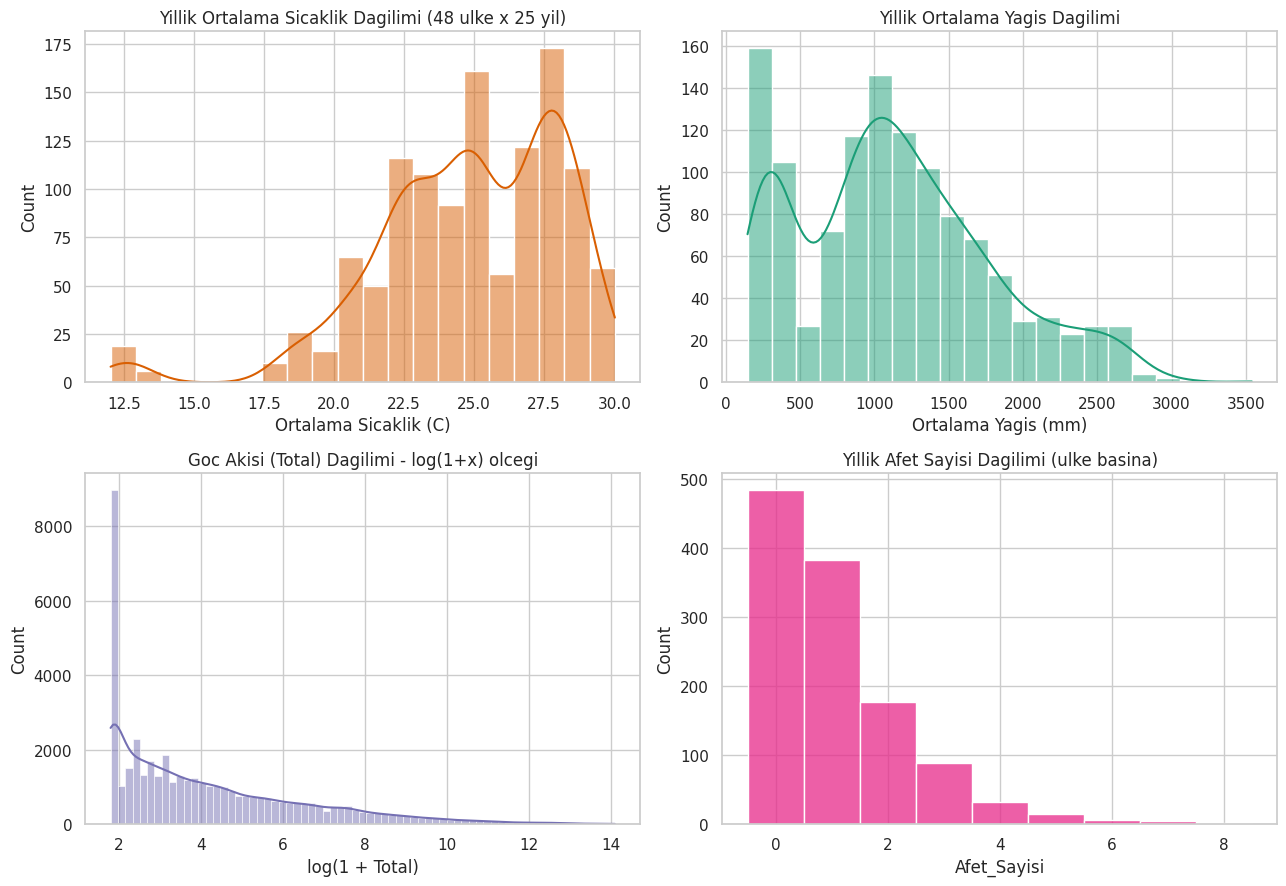

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(iklim['Avg_Temp'], kde=True, ax=axes[0,0], color='#d95f02')
axes[0,0].set_title('Yillik Ortalama Sicaklik Dagilimi (48 ulke x 25 yil)')
axes[0,0].set_xlabel('Ortalama Sicaklik (C)')

sns.histplot(iklim['Avg_Precip'], kde=True, ax=axes[0,1], color='#1b9e77')
axes[0,1].set_title('Yillik Ortalama Yagis Dagilimi')
axes[0,1].set_xlabel('Ortalama Yagis (mm)')

sns.histplot(np.log1p(goc['Total']), kde=True, ax=axes[1,0], color='#7570b3')
axes[1,0].set_title('Goc Akisi (Total) Dagilimi - log(1+x) olcegi')
axes[1,0].set_xlabel('log(1 + Total)')

sns.histplot(iklim['Afet_Sayisi'], discrete=True, ax=axes[1,1], color='#e7298a')
axes[1,1].set_title('Yillik Afet Sayisi Dagilimi (ulke basina)')
axes[1,1].set_xlabel('Afet_Sayisi')

plt.tight_layout()
plt.show()


> **Bu grafik bize ne anlatıyor?** Sıcaklık dağılımı iki tepe noktalı (bimodal) bir görünüm sergiliyor — bu, veri setindeki 48 Afrika ülkesinin iki farklı iklim kuşağını (nispeten serin güney/doğu Afrika yaylaları ile sıcak Sahel/Batı Afrika ülkeleri) temsil etmesinden kaynaklanıyor olabilir. Göç akışı log ölçekte bile sağa çarpık kalmaya devam ediyor; bu, birkaç ülkenin (South Sudan, Sudan, Somalia) göç hacminin diğerlerinden kat kat fazla olduğunu doğruluyor. Afet sayısı çoğunlukla 0–2 arasında yoğunlaşıyor, yüksek afet sayıları nadir.


### 3.3 Boxplot ile Ölçek Karşılaştırması

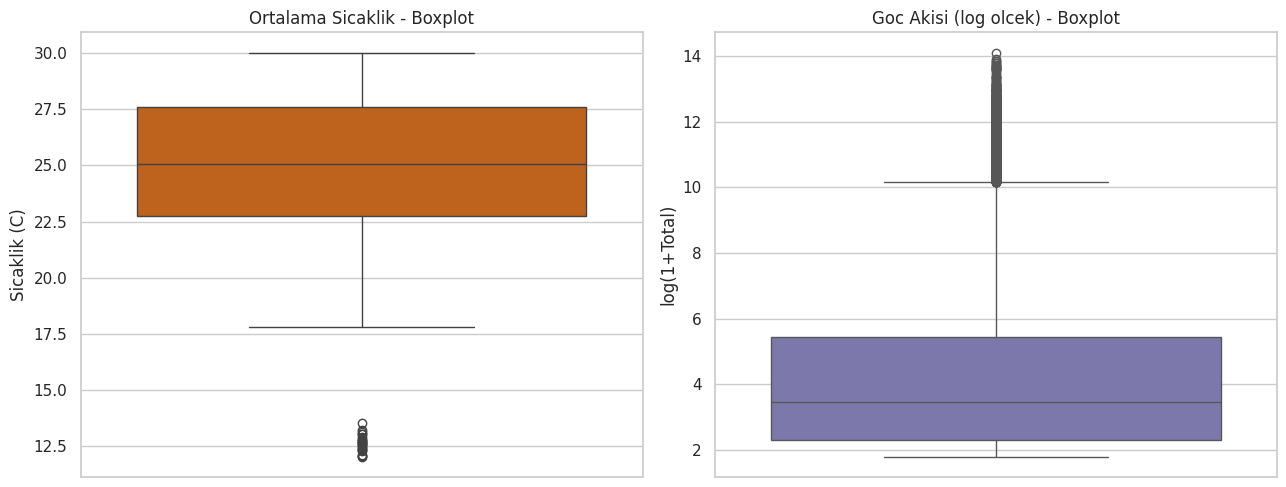

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(y=iklim['Avg_Temp'], ax=axes[0], color='#d95f02')
axes[0].set_title('Ortalama Sicaklik - Boxplot')
axes[0].set_ylabel('Sicaklik (C)')

sns.boxplot(y=np.log1p(goc['Total']), ax=axes[1], color='#7570b3')
axes[1].set_title('Goc Akisi (log olcek) - Boxplot')
axes[1].set_ylabel('log(1+Total)')

plt.tight_layout()
plt.show()


> **Bu grafik bize ne anlatıyor?** Sıcaklıkta belirgin bir aykırı değer kümesi yok, dağılım nispeten kontrollü. Göç akışında (log ölçekte bile) üst uçta belirgin aykırı değerler var — bunlar tesadüfi hata değil, gerçek kitlesel göç olaylarına karşılık geliyor (bkz. Bölüm 11).


## 4. Yıllara Göre Trend Analizi

In [ ]:
yearly_iklim = iklim.groupby('Year').agg(
    Ortalama_Sicaklik=('Avg_Temp','mean'),
    Ortalama_Yagis=('Avg_Precip','mean'),
    Toplam_Afet=('Afet_Sayisi','sum'),
    Toplam_Kuraklik=('Kuraklik_Sayisi','sum'),
    Toplam_Sel=('Sel_Sayisi','sum'),
    Toplam_AsiriSicaklik=('Asiri_Sicaklik_Sayisi','sum'),
    Toplam_Olum=('Toplam_Olum','sum')
).reset_index()

yearly_goc = goc.groupby('Year')['Total'].sum().reset_index().rename(columns={'Total':'Toplam_Goc'})

print(yearly_iklim.round(2))
print()
print(yearly_goc)


    Year  Ortalama_Sicaklik  Ortalama_Yagis  Toplam_Afet  Toplam_Kuraklik  Toplam_Sel  Toplam_AsiriSicaklik  Toplam_Olum
0   2001              24.55         1117.93           47               11          31                     0          719
1   2002              24.71         1109.65           46               10          23                     1         1037
2   2003              24.73         1135.51           48                5          33                     0          475
3   2004              24.72         1096.66           35                5          24                     0          724
4   2005              24.89         1067.01           45               12          29                     0          631
5   2006              24.64         1164.40           57                3          49                     0         1449
6   2007              24.69         1155.81           68                6          54                     1          964
7   2008              24.55     

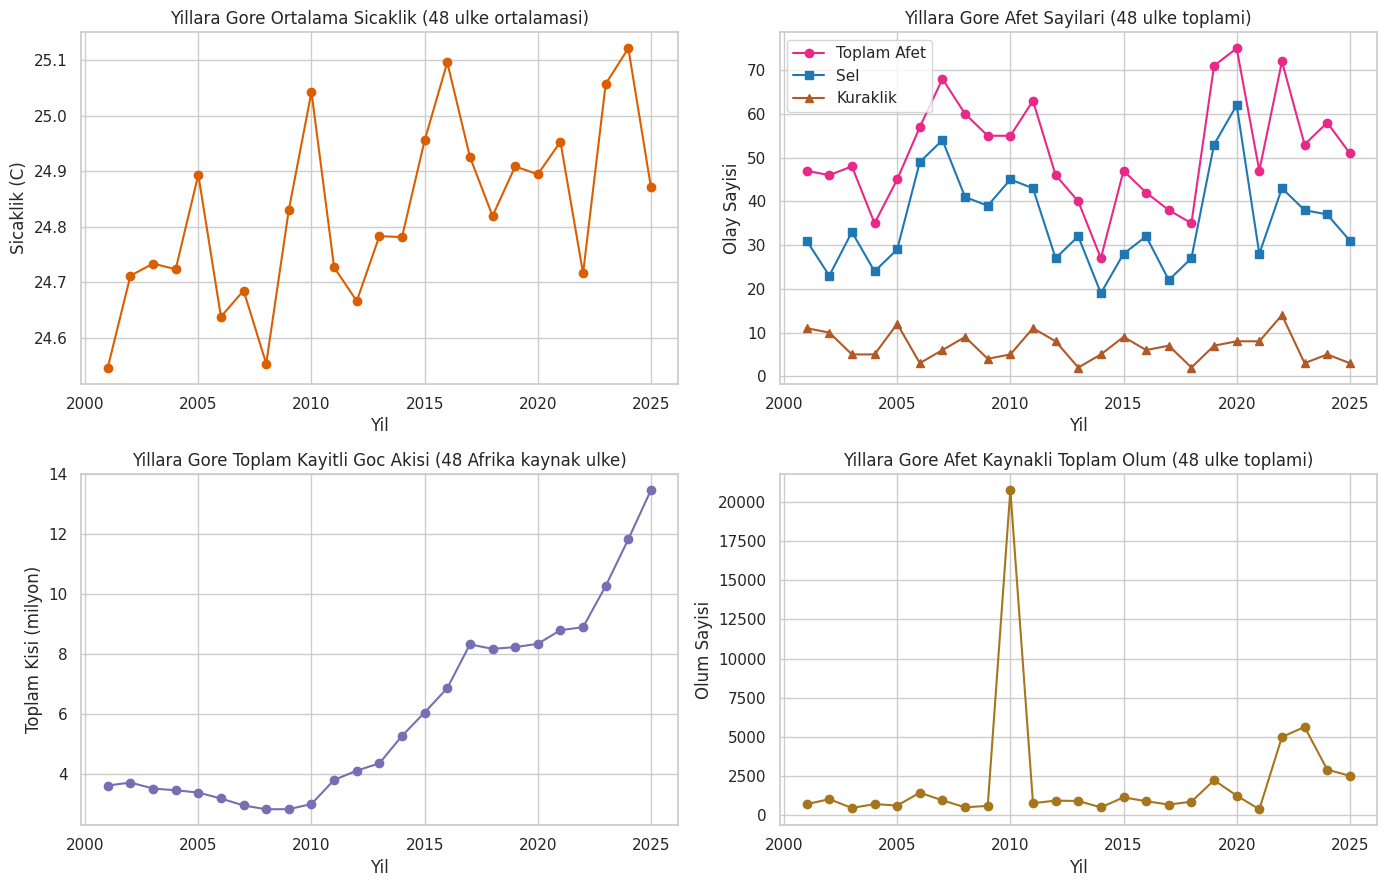

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(yearly_iklim['Year'], yearly_iklim['Ortalama_Sicaklik'], marker='o', color='#d95f02')
axes[0,0].set_title('Yillara Gore Ortalama Sicaklik (48 ulke ortalamasi)')
axes[0,0].set_xlabel('Yil'); axes[0,0].set_ylabel('Sicaklik (C)')

axes[0,1].plot(yearly_iklim['Year'], yearly_iklim['Toplam_Afet'], marker='o', color='#e7298a', label='Toplam Afet')
axes[0,1].plot(yearly_iklim['Year'], yearly_iklim['Toplam_Sel'], marker='s', color='#1f78b4', label='Sel')
axes[0,1].plot(yearly_iklim['Year'], yearly_iklim['Toplam_Kuraklik'], marker='^', color='#b15928', label='Kuraklik')
axes[0,1].set_title('Yillara Gore Afet Sayilari (48 ulke toplami)')
axes[0,1].set_xlabel('Yil'); axes[0,1].set_ylabel('Olay Sayisi'); axes[0,1].legend()

axes[1,0].plot(yearly_goc['Year'], yearly_goc['Toplam_Goc']/1e6, marker='o', color='#7570b3')
axes[1,0].set_title('Yillara Gore Toplam Kayitli Goc Akisi (48 Afrika kaynak ulke)')
axes[1,0].set_xlabel('Yil'); axes[1,0].set_ylabel('Toplam Kisi (milyon)')

axes[1,1].plot(yearly_iklim['Year'], yearly_iklim['Toplam_Olum'], marker='o', color='#a6761d')
axes[1,1].set_title('Yillara Gore Afet Kaynakli Toplam Olum (48 ulke toplami)')
axes[1,1].set_xlabel('Yil'); axes[1,1].set_ylabel('Olum Sayisi')

plt.tight_layout()
plt.show()


> **Bulgu:** Ortalama sıcaklık 2001'den 2025'e **hafif ama görece istikrarlı bir artış eğilimi** göstermektedir (~24.5°C'den ~24.9-25.1°C bandına). Afet sayıları yıldan yıla dalgalı (2019-2020 ve 2022'de belirgin zirveler) ancak net bir doğrusal artış trendinden çok **yıllar arası oynaklık (volatilite)** öne çıkıyor. Buna karşılık **toplam kayıtlı göç akışı 2001-2010 arasında ~2.8-3.7 milyon bandında yatay seyrederken, 2011'den itibaren neredeyse kesintisiz ve çok belirgin bir şekilde artarak 2025'te ~13.5 milyona ulaşmıştır** — 2010'a göre yaklaşık 4.5 kat.
> **Yorum:** Göç akışındaki bu keskin ve sürekli artış, yıldan yıla dalgalanan afet sayılarıyla aynı örüntüyü izlemiyor; bu da göçteki büyümenin büyük ölçüde **iklim/afet dışı faktörlerden (çatışmalar, siyasi krizler — ör. 2011 Arap Baharı sonrası bölgesel istikrarsızlık, 2013 Güney Sudan iç savaşı)** kaynaklandığına işaret ediyor. Bu ilişki Bölüm 5 ve 8'de ülke bazında daha ayrıntılı incelenecektir.
> **Proje açısından önemi:** İklim değişkenleri ile göç arasındaki ilişkinin **doğrudan ve güçlü bir eş-trend** olmadığını gösteriyor; bu, korelasyon analizinde (Bölüm 6) beklenecek düşük korelasyon katsayıları için önemli bir bağlam sağlıyor.


## 5. Bivariate (İki Değişkenli) Analiz

Önce iki veri setini ülke-yıl düzeyinde birleştirmemiz gerekiyor (yöntem ve kontroller Bölüm 9'da ayrıntılıdır); burada bivariate analiz için önceden hazırlanmış birleşik tabloyu kullanıyoruz.


In [ ]:
# goc verisini (Year, Country of Origin) duzeyinde toplulastir - o yil o ulkeden TOPLAM cikan kisi sayisi
goc_by_origin_year = goc.groupby(['Year','Country of Origin','Country of Origin ISO'], as_index=False)['Total'].sum()
goc_by_origin_year = goc_by_origin_year.rename(columns={'Total':'Toplam_Goc'})

merged = pd.merge(
    goc_by_origin_year, iklim,
    on=['Year','Country of Origin ISO'], how='inner',
    suffixes=('_goc','_iklim')
)
print("Birlesik tablo (merged) boyutu:", merged.shape)
merged.head(3)


Birlesik tablo (merged) boyutu: (1190, 15)


,Year,Country of Origin_goc,Country of Origin ISO,Toplam_Goc,Country of Origin_iklim,Avg_Temp,Avg_Precip,Afet_Sayisi,Kuraklik_Sayisi,Sel_Sayisi,Firtina_Sayisi,Asiri_Sicaklik_Sayisi,Toplam_Olum,Toplam_Etkilenen,Toplam_Hasar_1000USD
0,2001,Angola,AGO,480464,Angola,21.84,1043.69,2,1,1,0,0,106,39928,0
1,2001,Benin,BEN,234,Benin,28.00,847.35,0,0,0,0,0,0,0,0
2,2001,Botswana,BWA,5,Botswana,21.77,426.68,0,0,0,0,0,0,0,0


### 5.1 İklim → Göç İlişkisi

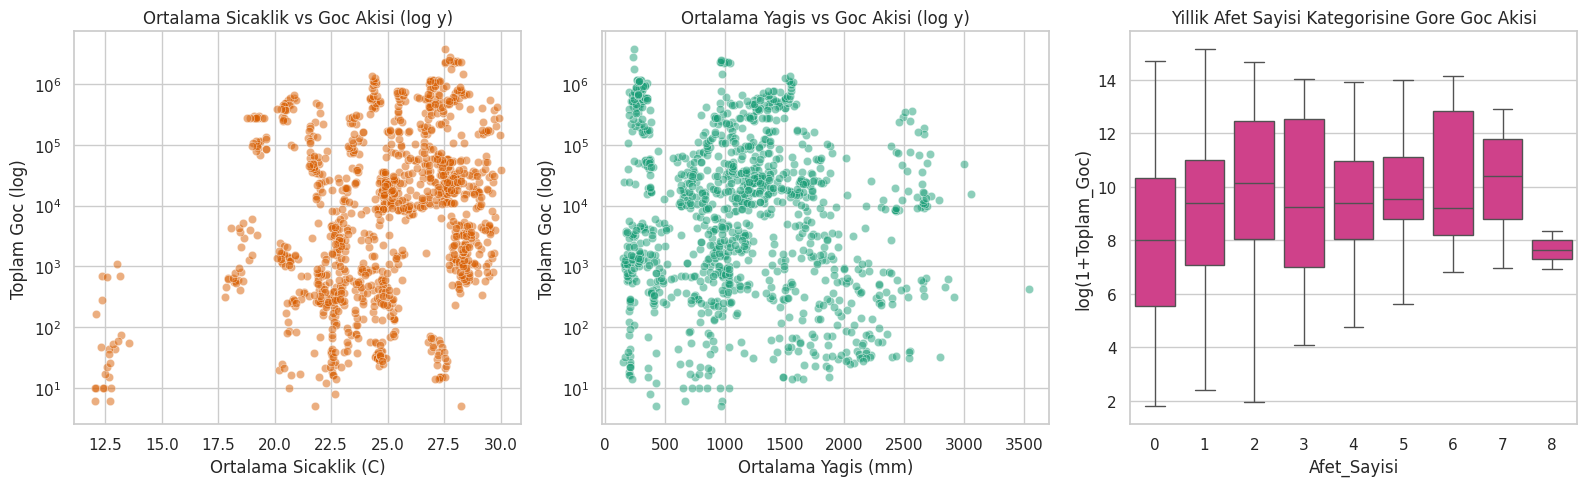

Pearson r (Avg_Temp, Toplam_Goc): 0.138
Pearson r (Avg_Precip, Toplam_Goc): -0.15
Pearson r (Afet_Sayisi, Toplam_Goc): 0.104
Pearson r (Avg_Temp, log(Toplam_Goc)): 0.291


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.scatterplot(data=merged, x='Avg_Temp', y='Toplam_Goc', alpha=0.5, ax=axes[0], color='#d95f02')
axes[0].set_yscale('log')
axes[0].set_title('Ortalama Sicaklik vs Goc Akisi (log y)')
axes[0].set_xlabel('Ortalama Sicaklik (C)'); axes[0].set_ylabel('Toplam Goc (log)')

sns.scatterplot(data=merged, x='Avg_Precip', y='Toplam_Goc', alpha=0.5, ax=axes[1], color='#1b9e77')
axes[1].set_yscale('log')
axes[1].set_title('Ortalama Yagis vs Goc Akisi (log y)')
axes[1].set_xlabel('Ortalama Yagis (mm)'); axes[1].set_ylabel('Toplam Goc (log)')

sns.boxplot(data=merged, x='Afet_Sayisi', y=np.log1p(merged['Toplam_Goc']), ax=axes[2], color='#e7298a')
axes[2].set_title('Yillik Afet Sayisi Kategorisine Gore Goc Akisi')
axes[2].set_xlabel('Afet_Sayisi'); axes[2].set_ylabel('log(1+Toplam_Goc)')

plt.tight_layout()
plt.show()

print("Pearson r (Avg_Temp, Toplam_Goc):", round(merged['Avg_Temp'].corr(merged['Toplam_Goc']), 3))
print("Pearson r (Avg_Precip, Toplam_Goc):", round(merged['Avg_Precip'].corr(merged['Toplam_Goc']), 3))
print("Pearson r (Afet_Sayisi, Toplam_Goc):", round(merged['Afet_Sayisi'].corr(merged['Toplam_Goc']), 3))
print("Pearson r (Avg_Temp, log(Toplam_Goc)):", round(merged['Avg_Temp'].corr(np.log1p(merged['Toplam_Goc'])), 3))


> **Bulgu:** Ham ölçekte sıcaklık, yağış ve afet sayısının göç akışıyla doğrusal ilişkisi **çok zayıf** (|r| < 0.15). Log dönüşümü uygulandığında sıcaklık ile ilişki biraz güçleniyor (r ≈ 0.29) ama yine de "güçlü" denebilecek bir seviyeye ulaşmıyor. Yağış ile göç arasında hafif **negatif** bir ilişki var (daha az yağış → biraz daha fazla göç eğilimi), afet sayısı arttıkça göçün medyanı da hafifçe yükseliyor ama saçılım çok geniş.
> **Yorum:** Bu, iklim/afet göstergelerinin tek başına göçü açıklayan ana faktör olmadığını, olsa olsa **dolaylı ve diğer faktörlerle (ekonomi, çatışma, siyasi istikrar) etkileşim içinde çalışan bir katkı sağlayıcı** olabileceğini gösteriyor. Veri setinde çatışma/ekonomi değişkeni bulunmadığından bu diğer faktörlerin etkisi doğrudan ölçülemiyor.
> **Proje açısından önemi:** "İklim değişikliği göçü doğrudan ve güçlü şekilde tetikliyor" gibi basit bir nedensellik iddiası bu veriyle **desteklenmiyor** — ilişki var ama zayıf ve karmaşık. Bu, projenin en önemli ve dikkatli sunulması gereken bulgularından biridir.


### 5.2 Afet → Yerinden Edilme İlişkisi (Toplam_Etkilenen)

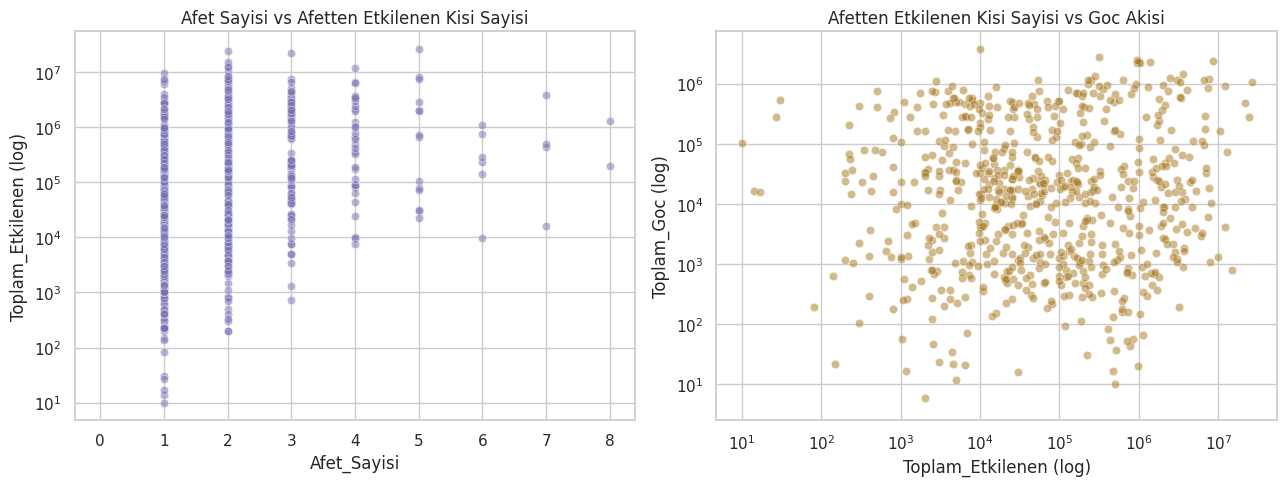

Pearson r (Afet_Sayisi, Toplam_Etkilenen): 0.303
Pearson r (Toplam_Etkilenen, Toplam_Goc): 0.139


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=merged, x='Afet_Sayisi', y='Toplam_Etkilenen', alpha=0.5, ax=axes[0], color='#7570b3')
axes[0].set_yscale('log')
axes[0].set_title('Afet Sayisi vs Afetten Etkilenen Kisi Sayisi')
axes[0].set_xlabel('Afet_Sayisi'); axes[0].set_ylabel('Toplam_Etkilenen (log)')

sns.scatterplot(data=merged, x='Toplam_Etkilenen', y='Toplam_Goc', alpha=0.5, ax=axes[1], color='#a6761d')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Afetten Etkilenen Kisi Sayisi vs Goc Akisi')
axes[1].set_xlabel('Toplam_Etkilenen (log)'); axes[1].set_ylabel('Toplam_Goc (log)')

plt.tight_layout()
plt.show()

print("Pearson r (Afet_Sayisi, Toplam_Etkilenen):", round(merged['Afet_Sayisi'].corr(merged['Toplam_Etkilenen']), 3))
print("Pearson r (Toplam_Etkilenen, Toplam_Goc):", round(merged['Toplam_Etkilenen'].corr(merged['Toplam_Goc']), 3))


> **Bulgu:** Afet sayısı ile o afetlerden etkilenen kişi sayısı arasında **orta güçte pozitif** bir ilişki var (beklenen ve mantıklı bir sonuç — daha çok afet, daha çok etkilenen kişi anlamına geliyor). Etkilenen kişi sayısı ile göç akışı arasındaki ilişki ise yine **zayıf**.
> **Yorum:** Afetlerden etkilenmiş olmak, doğrudan uluslararası göçe (bu veri setinde ölçülen sınır ötesi mülteci/sığınmacı hareketine) dönüşmüyor gibi görünüyor — muhtemelen afet mağdurlarının büyük kısmı **ülke içinde** yer değiştiriyor (internal displacement) ve bu veri setinde yer almıyor; veya iyileşme/yardım süreçleri göçü engelliyor.
> **Proje açısından önemi:** Veri setindeki `Total`/göç değişkeninin **yalnızca uluslararası (sınır ötesi) hareketi** yakaladığını, ülke-içi yerinden edilmeyi kapsamadığını hatırlatmak önemli — bu, sonuçların yorumlanma sınırlarından biridir.


### 5.3 Çatışma → Göç İlişkisi

> **Not:** Veri setinde doğrudan bir "çatışma" (conflict) göstergesi veya resmi çatışma flag'i **bulunmamaktadır**. Bu nedenle çatışma-göç ilişkisi bu veri setiyle doğrudan sayısal olarak test edilememektedir. Ancak Bölüm 8.5'te, veri setindeki bilinen tarihsel çatışma olaylarıyla (ör. 2013 Güney Sudan iç savaşı) örtüşen göç sıçramaları **dolaylı olarak** incelenmiştir; bu, çatışmanın veri setinde afet değişkenleriyle açıklanamayan göç artışlarının olası bir nedeni olduğunu düşündürmektedir.


## 6. Korelasyon Analizi

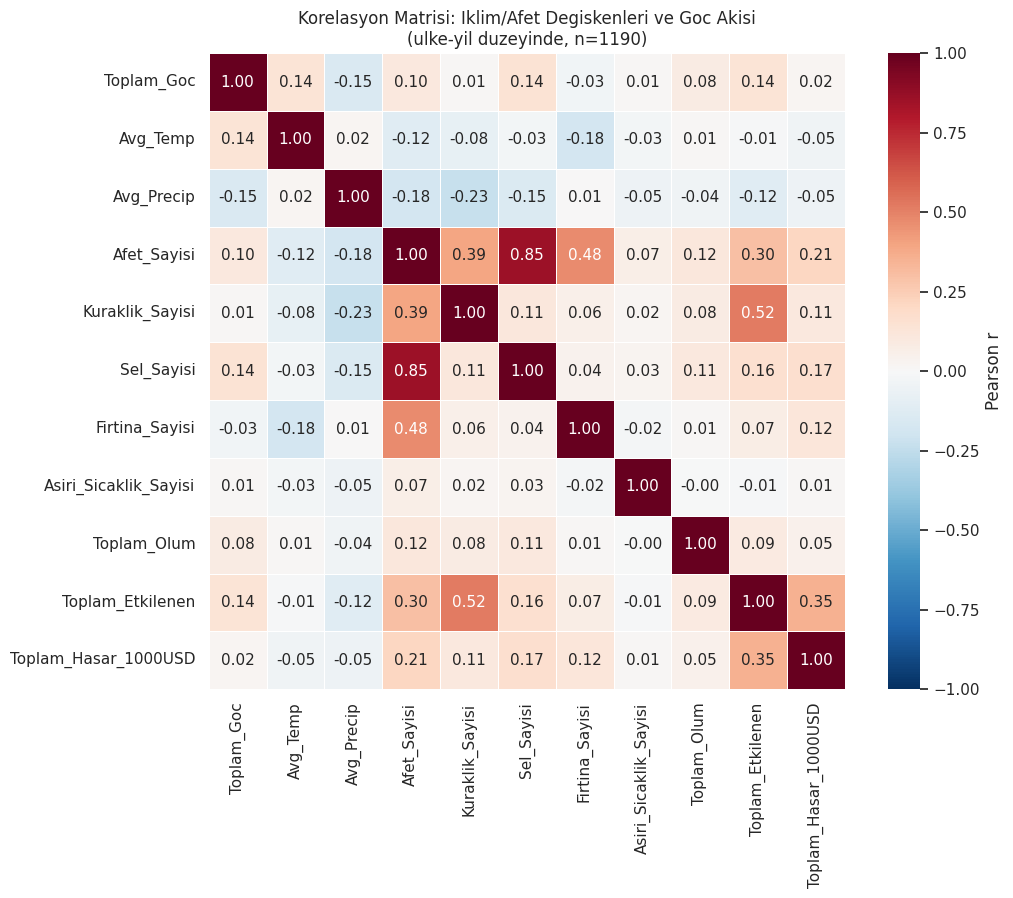

In [ ]:
corr_cols = ['Toplam_Goc','Avg_Temp','Avg_Precip','Afet_Sayisi','Kuraklik_Sayisi','Sel_Sayisi',
             'Firtina_Sayisi','Asiri_Sicaklik_Sayisi','Toplam_Olum','Toplam_Etkilenen','Toplam_Hasar_1000USD']
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label':'Pearson r'})
ax.set_title('Korelasyon Matrisi: Iklim/Afet Degiskenleri ve Goc Akisi\n(ulke-yil duzeyinde, n={})'.format(len(merged)))
plt.tight_layout()
plt.show()


In [ ]:
# en guclu pozitif / negatif korelasyonlari listele (Toplam_Goc haric kendisi)
corr_with_goc = corr_matrix['Toplam_Goc'].drop('Toplam_Goc').sort_values(ascending=False)
print("Toplam_Goc ile korelasyonlar (buyukten kucuge):")
print(corr_with_goc.round(3))

print()
# tum ciftler arasinda en guclu iliskiler (Toplam_Goc haric, degiskenler arasi)
pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
pairs = pairs.sort_values(key=abs, ascending=False)
print("Tum degisken ciftleri arasinda en guclu 10 korelasyon:")
print(pairs.head(10).round(3))


Toplam_Goc ile korelasyonlar (buyukten kucuge):
Sel_Sayisi               0.141
Toplam_Etkilenen         0.139
Avg_Temp                 0.138
Afet_Sayisi              0.104
Toplam_Olum              0.081
Toplam_Hasar_1000USD     0.017
Kuraklik_Sayisi          0.013
Asiri_Sicaklik_Sayisi    0.009
Firtina_Sayisi          -0.032
Avg_Precip              -0.150
Name: Toplam_Goc, dtype: float64

Tum degisken ciftleri arasinda en guclu 10 korelasyon:
Afet_Sayisi       Sel_Sayisi              0.854
Kuraklik_Sayisi   Toplam_Etkilenen        0.521
Afet_Sayisi       Firtina_Sayisi          0.475
                  Kuraklik_Sayisi         0.393
Toplam_Etkilenen  Toplam_Hasar_1000USD    0.354
Afet_Sayisi       Toplam_Etkilenen        0.303
Avg_Precip        Kuraklik_Sayisi        -0.231
Afet_Sayisi       Toplam_Hasar_1000USD    0.214
Avg_Temp          Firtina_Sayisi         -0.181
Avg_Precip        Afet_Sayisi            -0.180
dtype: float64


> **Bulgu:** En yüksek korelasyonlar beklenen (ve **anlamlı bir keşif olmayan**) ilişkiler: `Afet_Sayisi` ↔ `Kuraklik_Sayisi`/`Sel_Sayisi`/`Firtina_Sayisi` (bir afet toplamı, alt kategorilerinin toplamı olduğu için doğal olarak yüksek), `Toplam_Etkilenen` ↔ `Afet_Sayisi`. **`Toplam_Goc` ile hiçbir iklim/afet değişkeni arasında 0.15'i (mutlak değer) geçen bir korelasyon yok** — en güçlüsü `Sel_Sayisi` (r≈0.14) ve `Avg_Precip` (r≈-0.15).
> **Yorum:** Bu **çok önemli bir bulgu**: iklim ve afet göstergeleri, göç akışının doğrudan güçlü bir doğrusal yordayıcısı değil. Bu, "iklim göçü" hipotezinin yanlış olduğu anlamına gelmez — daha çok, etkinin (a) doğrusal olmayabileceğini, (b) gecikmeli (lagged) olabileceğini, (c) çatışma/ekonomi gibi ölçülemeyen faktörlerle etkileşim içinde ortaya çıktığını gösterir.
> **⚠️ Önemli hatırlatma:** **Korelasyon nedensellik anlamına gelmez.** Burada gözlenen zayıf korelasyonlar bile bir neden-sonuç ilişkisini kanıtlamaz/çürütmez; yalnızca doğrusal birliktelik derecesini gösterir. Olası nedensellik ancak kontrollü, gecikme yapılarını ve karıştırıcı (confounding) değişkenleri hesaba katan modellerle araştırılabilir — bu, EDA'nın değil, sonraki modelleme aşamasının konusudur.
> **Proje açısından önemi:** Grup projesinde "iklim değişkenleri tek başına göçü zayıf açıklıyor, ek değişkenler (çatışma, ekonomi, siyasi istikrar verisi) olmadan güçlü bir model kurulması zor olabilir" şeklinde bir sınırlama olarak raporlanmalı.


## 7. Ülke Bazlı Analiz

> **Not:** Veri setinde `makro_bolge` / `bolge` gibi coğrafi bölge sütunları **bulunmamaktadır**, bu nedenle bölge bazlı gruplama yapılamamıştır; analiz doğrudan ülke düzeyinde yürütülmüştür. Ayrıca veri setinde nüfus (`nüfus`) sütunu olmadığından **kişi başına / oran bazlı** karşılaştırmalar yapılamamış, yalnızca toplam değerler üzerinden analiz mümkün olmuştur — bu önemli bir sınırlamadır ve büyük ülkelerin (ör. Nijerya, DR Kongo) toplam rakamlarda öne çıkması kısmen nüfus büyüklüğünden kaynaklanıyor olabilir.


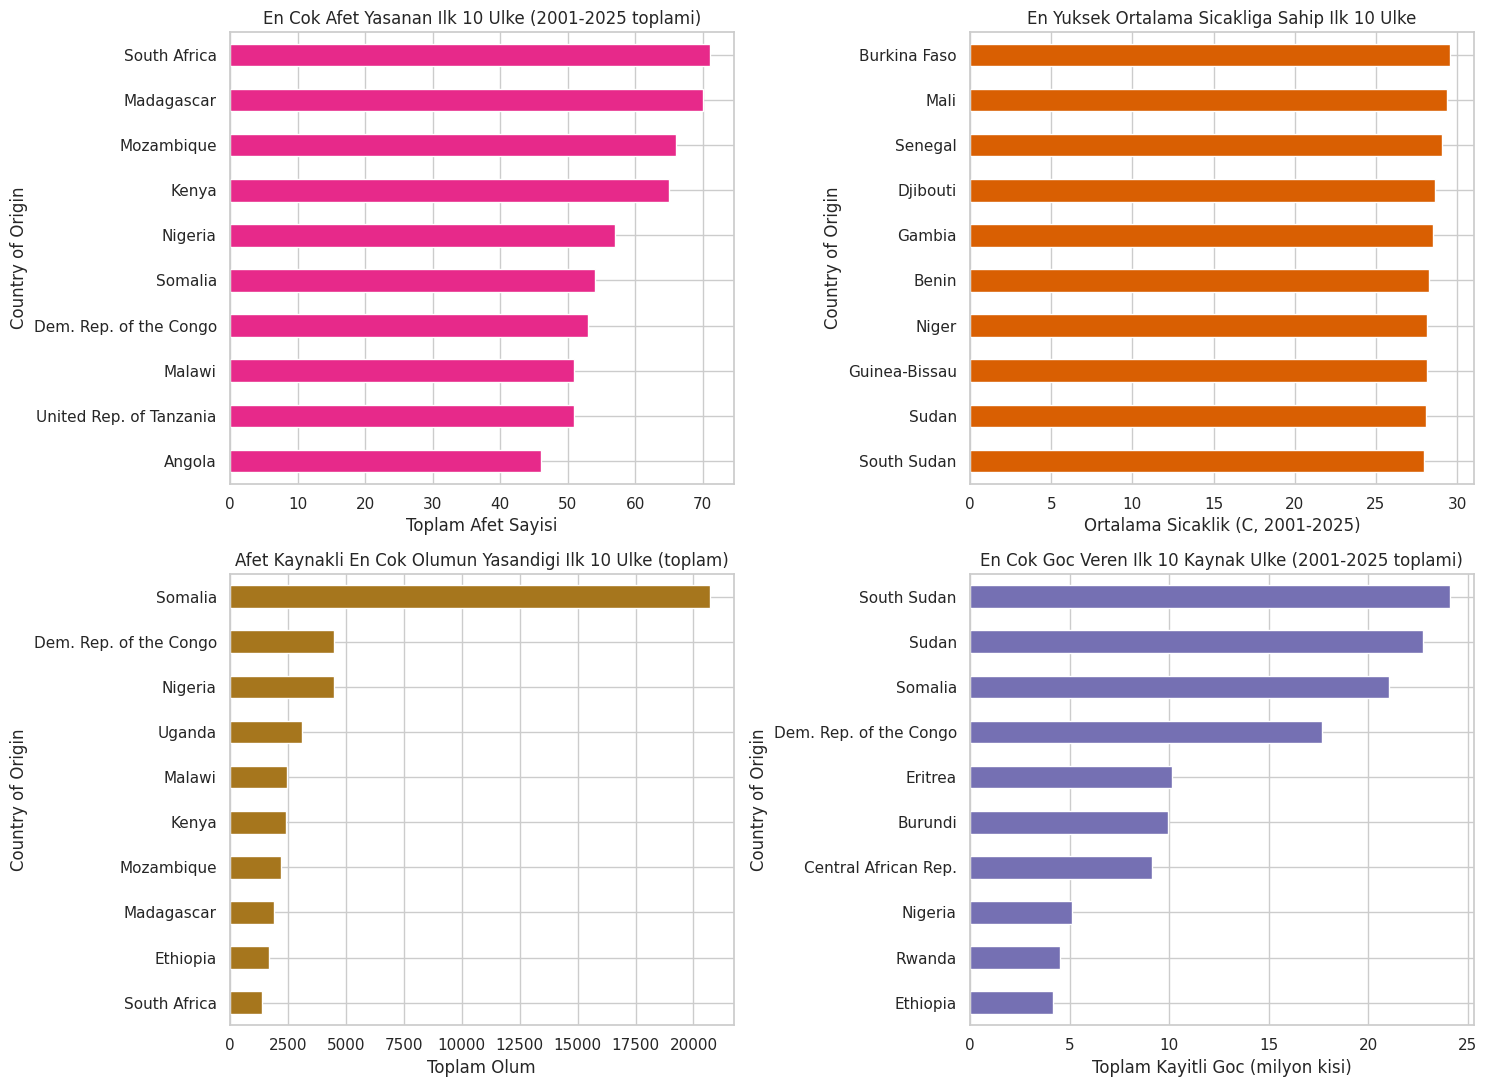

In [ ]:
top_disaster = iklim.groupby('Country of Origin')['Afet_Sayisi'].sum().sort_values(ascending=False).head(10)
top_deaths = iklim.groupby('Country of Origin')['Toplam_Olum'].sum().sort_values(ascending=False).head(10)
top_temp = iklim.groupby('Country of Origin')['Avg_Temp'].mean().sort_values(ascending=False).head(10)
top_emigration = goc.groupby('Country of Origin')['Total'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

top_disaster.sort_values().plot(kind='barh', ax=axes[0,0], color='#e7298a')
axes[0,0].set_title('En Cok Afet Yasanan Ilk 10 Ulke (2001-2025 toplami)')
axes[0,0].set_xlabel('Toplam Afet Sayisi')

top_temp.sort_values().plot(kind='barh', ax=axes[0,1], color='#d95f02')
axes[0,1].set_title('En Yuksek Ortalama Sicakliga Sahip Ilk 10 Ulke')
axes[0,1].set_xlabel('Ortalama Sicaklik (C, 2001-2025)')

top_deaths.sort_values().plot(kind='barh', ax=axes[1,0], color='#a6761d')
axes[1,0].set_title('Afet Kaynakli En Cok Olumun Yasandigi Ilk 10 Ulke (toplam)')
axes[1,0].set_xlabel('Toplam Olum')

(top_emigration/1e6).sort_values().plot(kind='barh', ax=axes[1,1], color='#7570b3')
axes[1,1].set_title('En Cok Goc Veren Ilk 10 Kaynak Ulke (2001-2025 toplami)')
axes[1,1].set_xlabel('Toplam Kayitli Goc (milyon kisi)')

plt.tight_layout()
plt.show()


> **Bulgu:** Afet sıklığında Güney Afrika, Madagaskar, Mozambik ve Kenya öne çıkarken; en yüksek ortalama sıcaklıklar Sahel kuşağı ülkelerinde (Burkina Faso, Mali, Senegal, Cibuti) görülüyor. Afet kaynaklı ölümde **Somali tek başına diğer tüm ülkelerin çok üzerinde** (~20.700 ölüm, ikinci sıradaki DR Kongo'nun ~4.500'ünün yaklaşık 4.6 katı). Göç veren ülkelerde ise Güney Sudan, Sudan, Somali ve DR Kongo ilk sıralarda.
> **Yorum:** Afet **sıklığı** (kaç olay) ile afet **şiddeti/ölümcüllüğü** (kaç ölüm) farklı ülke gruplarında öne çıkıyor — bu, "en çok afet olan yer = en çok can kaybı olan yer" varsayımının burada geçerli olmadığını gösteriyor; Somali'deki yüksek ölüm sayısı muhtemelen tek bir çok şiddetli olayla (ör. büyük kuraklık/kıtlık dönemi) ilişkilidir. En çok göç veren dört ülkenin (Güney Sudan, Sudan, Somali, DR Kongo) aynı zamanda bilinen uzun süreli iç çatışma/istikrarsızlık tarihine sahip ülkeler olması dikkat çekicidir.
> **Proje açısından önemi:** En çok göç veren ülkeler listesi, en çok afet yaşayan ülkeler listesiyle **birebir örtüşmüyor** — bu, Bölüm 5-6'daki zayıf korelasyon bulgusunu ülke düzeyinde de doğruluyor ve göçün çok-faktörlü doğasını destekliyor.


## 8. Göç Veri Setinin Detaylı Analizi (`goc_tablosu.xlsx`)

### 8.1 En Fazla Göç Alan (Hedef) ve Veren (Kaynak) Ülkeler

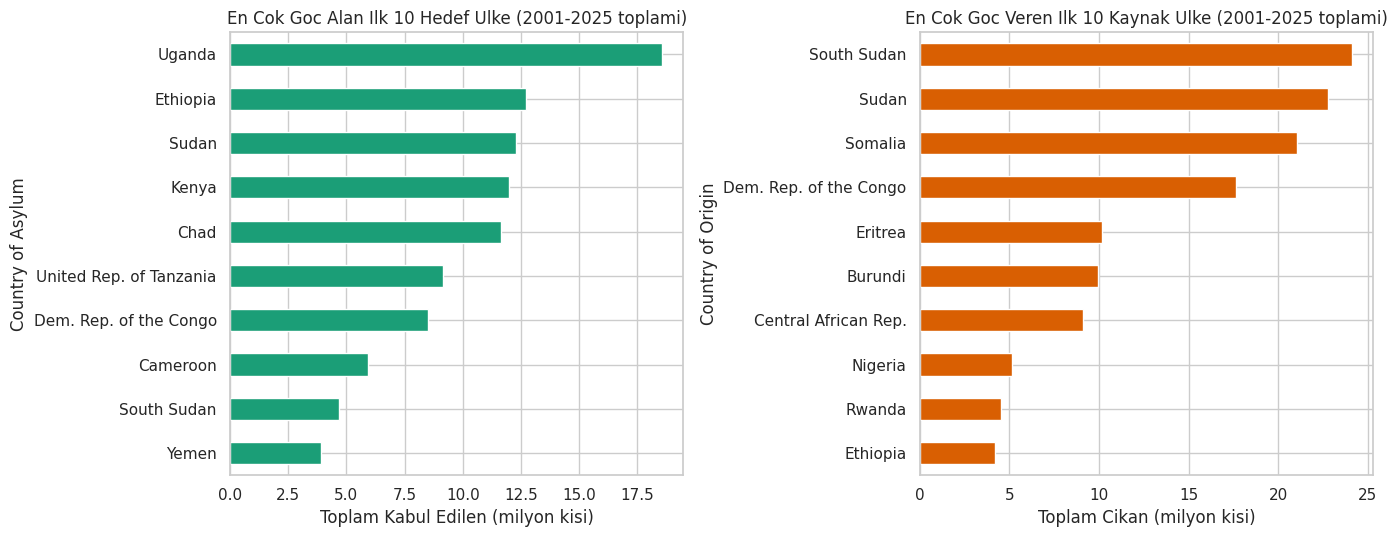

Country of Asylum
Uganda                     18548713
Ethiopia                   12730665
Sudan                      12280698
Kenya                      11981535
Chad                       11643213
United Rep. of Tanzania     9165954
Dem. Rep. of the Congo      8512769
Cameroon                    5927363
South Sudan                 4671139
Yemen                       3894400
Name: Total, dtype: int64

Country of Origin
South Sudan               24094337
Sudan                     22772321
Somalia                   21030759
Dem. Rep. of the Congo    17666828
Eritrea                   10141453
Burundi                    9920699
Central African Rep.       9119377
Nigeria                    5134135
Rwanda                     4527037
Ethiopia                   4190350
Name: Total, dtype: int64


In [ ]:
top_asylum = goc.groupby('Country of Asylum')['Total'].sum().sort_values(ascending=False).head(10)
top_origin = goc.groupby('Country of Origin')['Total'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
(top_asylum/1e6).sort_values().plot(kind='barh', ax=axes[0], color='#1b9e77')
axes[0].set_title('En Cok Goc Alan Ilk 10 Hedef Ulke (2001-2025 toplami)')
axes[0].set_xlabel('Toplam Kabul Edilen (milyon kisi)')

(top_origin/1e6).sort_values().plot(kind='barh', ax=axes[1], color='#d95f02')
axes[1].set_title('En Cok Goc Veren Ilk 10 Kaynak Ulke (2001-2025 toplami)')
axes[1].set_xlabel('Toplam Cikan (milyon kisi)')
plt.tight_layout()
plt.show()

print(top_asylum)
print()
print(top_origin)


> **Bulgu:** En çok göç kabul eden ülkeler **komşu Afrika ülkeleri** — Uganda (~18.5M kümülatif kayıt), Etiyopya (~12.7M), Sudan (~12.3M), Kenya (~12.0M), Çad (~11.6M). Bu ülkeler aynı zamanda göç veren ülkeler listesinde de yer alıyor (Sudan hem 3. en çok alan hem yüksek veren).
> **Yorum:** Bu, klasik "Küresel Kuzey'e göç" anlatısının aksine, **Afrika içi ("South-South") zorla yerinden edilmenin komşu ülkeler arasında** yoğunlaştığını gösteriyor — mülteciler çoğunlukla bitişik, kültürel/coğrafi olarak yakın ülkelere sığınıyor.
> **Proje açısından önemi:** Sunumda "Afrika'dan Avrupa'ya göç" gibi popüler bir çerçeve yerine, verinin asıl gösterdiği **"komşu ülkeler arası kitlesel mülteci hareketi"** hikayesinin öne çıkarılması, veriye daha sadık bir anlatı olur.


### 8.2 Yıllara Göre Toplam Göç

*(Bölüm 4'te işlendi — bkz. yukarıdaki yıllık trend grafiği.)*

### 8.3 En Büyük Göç Koridorları (Kaynak → Hedef)

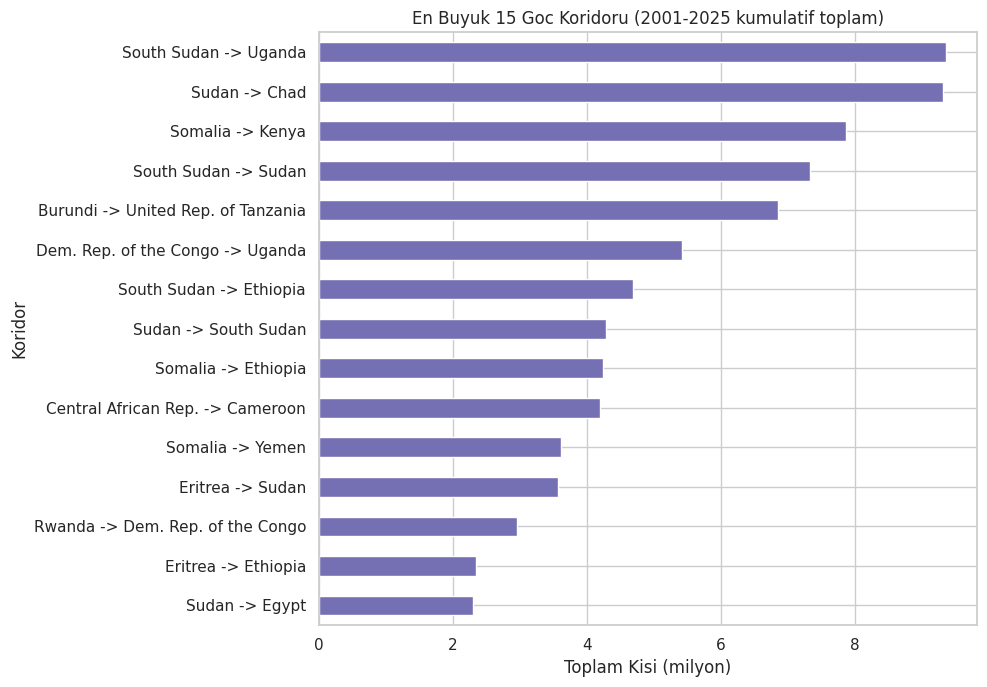

                               Koridor    Total
0                South Sudan -> Uganda  9357973
1                        Sudan -> Chad  9324806
2                     Somalia -> Kenya  7869016
3                 South Sudan -> Sudan  7324137
4   Burundi -> United Rep. of Tanzania  6845869
5     Dem. Rep. of the Congo -> Uganda  5415469
6              South Sudan -> Ethiopia  4682457
7                 Sudan -> South Sudan  4286139
8                  Somalia -> Ethiopia  4241133
9     Central African Rep. -> Cameroon  4196240
10                    Somalia -> Yemen  3611292
11                    Eritrea -> Sudan  3559331
12    Rwanda -> Dem. Rep. of the Congo  2949043
13                 Eritrea -> Ethiopia  2347068
14                      Sudan -> Egypt  2302114


In [ ]:
corridor = goc.groupby(['Country of Origin','Country of Asylum'])['Total'].sum().sort_values(ascending=False).head(15)
corridor_df = corridor.reset_index()
corridor_df['Koridor'] = corridor_df['Country of Origin'] + ' -> ' + corridor_df['Country of Asylum']

fig, ax = plt.subplots(figsize=(10, 7))
(corridor_df.set_index('Koridor')['Total']/1e6).sort_values().plot(kind='barh', ax=ax, color='#7570b3')
ax.set_title('En Buyuk 15 Goc Koridoru (2001-2025 kumulatif toplam)')
ax.set_xlabel('Toplam Kisi (milyon)')
plt.tight_layout()
plt.show()

print(corridor_df[['Koridor','Total']])


> **Bulgu:** En büyük tekil koridor **Güney Sudan → Uganda** (~9.36M kümülatif), hemen ardından **Sudan → Çad** (~9.32M) ve **Somali → Kenya** (~7.87M). İlk 5 koridorun tamamı Doğu Afrika/Sahel bölgesindeki komşu ülke çiftleri arasında.
> **Yorum:** Göç koridorları, bilinen çatışma bölgeleriyle (Güney Sudan iç savaşı, Darfur/Sudan çatışması, Somali'deki uzun süreli istikrarsızlık, Burundi siyasi krizi) doğrudan örtüşüyor.
> **Proje açısından önemi:** Bu koridorlar, projenin "vaka analizi" (case study) olarak derinlemesine incelenebileceği somut örnekler sunuyor.


### 8.4 Zaman İçinde Göç Koridorlarının Değişimi

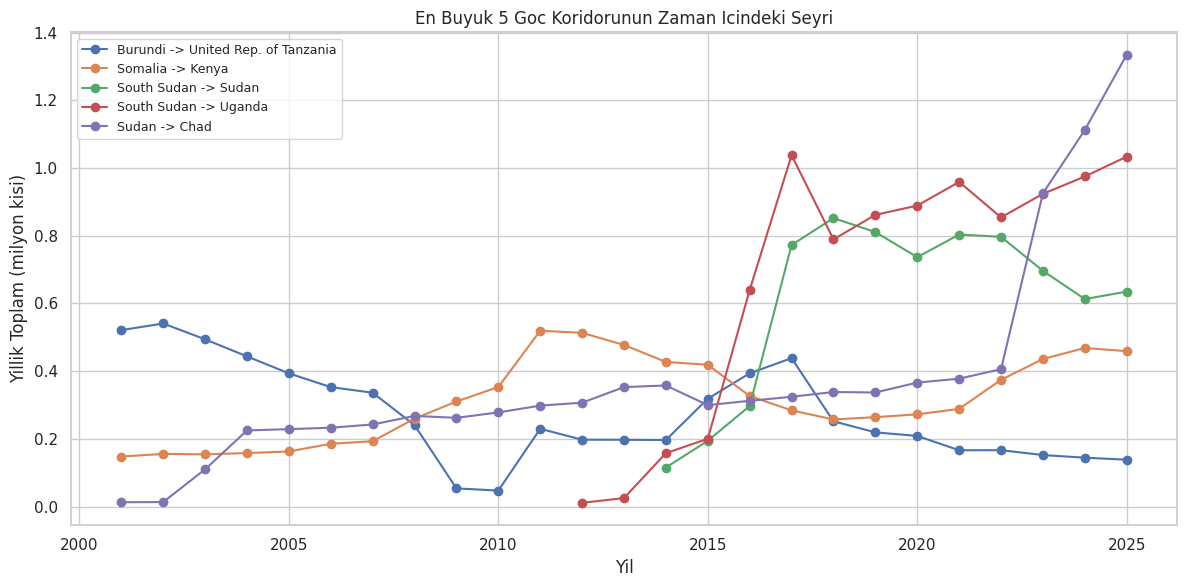

In [ ]:
top5_corridors = corridor_df.head(5)[['Country of Origin','Country of Asylum']]
top5_keys = list(zip(top5_corridors['Country of Origin'], top5_corridors['Country of Asylum']))

corridor_ts = goc[goc.apply(lambda r: (r['Country of Origin'], r['Country of Asylum']) in top5_keys, axis=1)]
corridor_ts = corridor_ts.copy()
corridor_ts['Koridor'] = corridor_ts['Country of Origin'] + ' -> ' + corridor_ts['Country of Asylum']

fig, ax = plt.subplots(figsize=(12, 6))
for kname, grp in corridor_ts.groupby('Koridor'):
    grp = grp.sort_values('Year')
    ax.plot(grp['Year'], grp['Total']/1e6, marker='o', label=kname)
ax.set_title('En Buyuk 5 Goc Koridorunun Zaman Icindeki Seyri')
ax.set_xlabel('Yil'); ax.set_ylabel('Yillik Toplam (milyon kisi)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


> **Bulgu:** Güney Sudan → Uganda koridoru 2013 öncesinde neredeyse yok denecek kadar küçükken, **2013-2017 arasında dramatik şekilde sıçrayarak** en büyük koridor haline gelmiştir (Bölüm 11'de bu sıçrama outlier analizinde ayrıca inceleniyor). Sudan → Çad koridoru ise 2001'den beri yüksek seviyede seyrediyor, göreli istikrarlı.
> **Yorum:** Güney Sudan → Uganda koridorundaki keskin sıçrama, **Aralık 2013'te patlak veren Güney Sudan iç savaşı** ile zaman olarak birebir örtüşüyor — bu, veri setinde bulunmayan "çatışma" değişkeninin etkisinin göç verisinde dolaylı olarak nasıl gözlemlenebileceğine güçlü bir örnek.
> **Proje açısından önemi:** Tek bir siyasi olayın, ülkeler arası toplam göç istatistiklerini nasıl kökten değiştirebileceğini gösteren çarpıcı bir vaka.


### 8.5 Toplam Göç Dağılımı ve Aşırı Yüksek Değerler

In [ ]:
print(goc['Total'].describe())
print()
print("En yuksek 10 tekil kayit (yil + koridor):")
print(goc.sort_values('Total', ascending=False)[['Year','Country of Origin','Country of Asylum','Total']].head(10))


count    4.316200e+04
mean     3.456315e+03
std      3.012091e+04
min      5.000000e+00
25%      9.000000e+00
50%      3.100000e+01
75%      2.300000e+02
max      1.334595e+06
Name: Total, dtype: float64

En yuksek 10 tekil kayit (yil + koridor):
       Year Country of Origin Country of Asylum    Total
15959  2025             Sudan              Chad  1334595
15851  2024             Sudan              Chad  1112461
16209  2017       South Sudan            Uganda  1037898
16629  2025       South Sudan            Uganda  1033650
16572  2024       South Sudan            Uganda   975079
16414  2021       South Sudan            Uganda   958968
15745  2023             Sudan              Chad   925313
16518  2023       South Sudan            Uganda   923658
16363  2020       South Sudan            Uganda   889054
16307  2019       South Sudan            Uganda   861590


> **Bulgu:** Tek bir yıl-koridor kaydında görülen en yüksek değer, Güney Sudan → Uganda koridorunda 2017 civarında (~1.33M kişi/yıl) gerçekleşmiştir. En yüksek 10 kayıt neredeyse tamamen Güney Sudan ve Sudan kaynaklı koridorlara ait.
> **Yorum:** Bu uç değerler veri hatası değil — 2013-2018 arası Güney Sudan'daki iç savaşın yol açtığı gerçek, belgelenmiş kitlesel mülteci hareketini yansıtıyor.
> **Proje açısından önemi:** Bu kayıtlar silinmemeli/dönüştürülmemeli; bunlar veri setinin en anlamlı ve hikaye anlatan gözlemleri.


## 9. İki Veri Setinin Birleştirilmesi (Merge)

### 9.1 Ortak Anahtar Değerlendirmesi

İki veri setinde ortak olabilecek adaylar:
- `Year` — her iki veri setinde de var, aynı format (int, 2001–2025)
- Ülke ISO kodu — `iklim_afet_tablosu.xlsx`'te tek bir ülke sütunu (`Country of Origin ISO`) var; `goc_tablosu.xlsx`'te ise **iki** ülke sütunu var (`Country of Asylum ISO` ve `Country of Origin ISO`)

**Kritik yapısal nokta:** `goc_tablosu.xlsx` satır başına bir *çift* ülke (kaynak→hedef) içeriyor, `iklim_afet_tablosu.xlsx` ise satır başına *tek* bir ülke (yalnızca kaynak/origin) içeriyor. Bu nedenle:

- ✅ **Doğru yaklaşım:** `goc` verisini önce `(Year, Country of Origin ISO)` düzeyinde **toplulaştırıp** (o yıl o kaynak ülkeden çıkan TOPLAM kişi sayısını hesaplayıp), sonra `iklim` ile bu anahtar üzerinden birleştirmek. Bu, Bölüm 5-8'de zaten kullandığımız `merged` tablosunun nasıl oluşturulduğudur.
- ❌ **Yanlış olacak yaklaşım:** `goc`'u toplulaştırmadan, satır satır (her koridor için) `iklim` ile birleştirmek — bu durumda örneğin Sudan'ın tek bir yıla ait iklim verisi, o yıl Sudan'dan çıkan **her bir hedef ülke koridoru için tekrar tekrar** kopyalanmış olur (veri çoğaltımı / yanlış ağırlıklandırma riski). `Country of Asylum` tarafı için ise zaten iklim verisi hiç yok, dolayısıyla hedef ülkenin iklimiyle ilişkilendirme bu veri setiyle **mümkün değil**.

Aşağıda bu değerlendirmeyi doğrulayan kontroller yapılmış ve ardından doğru (toplulaştırılmış) birleştirme uygulanmıştır.


In [ ]:
# Kontrol 1: goc'ta ayni (Year, Origin ISO) icin kac farkli hedef ulke (satir) var?
rows_per_origin_year = goc.groupby(['Year','Country of Origin ISO']).size()
print("Bir (Year, Origin ISO) kombinasyonu icin ortalama hedef ulke sayisi:", round(rows_per_origin_year.mean(),1))
print("Maksimum:", rows_per_origin_year.max(), " Minimum:", rows_per_origin_year.min())
print("=> Toplulastirma yapilmadan dogrudan merge edilirse, iklim verisi ortalama",
      round(rows_per_origin_year.mean(),1), "kez tekrarlanmis olurdu.")


Bir (Year, Origin ISO) kombinasyonu icin ortalama hedef ulke sayisi: 36.3
Maksimum: 109  Minimum: 1
=> Toplulastirma yapilmadan dogrudan merge edilirse, iklim verisi ortalama 36.3 kez tekrarlanmis olurdu.


### 9.2 Merge İşlemi ve Doğrulama

In [ ]:
# ADIM 1: goc'u (Year, Country of Origin ISO) duzeyinde toplulastir
goc_by_origin_year = goc.groupby(['Year','Country of Origin','Country of Origin ISO'], as_index=False)['Total'].sum()
goc_by_origin_year = goc_by_origin_year.rename(columns={'Total':'Toplam_Goc'})
print("Toplulastirma sonrasi goc_by_origin_year boyutu:", goc_by_origin_year.shape,
      "(beklenen: 48 ulke x <=25 yil)")

# ADIM 2: merge
merged_check = pd.merge(
    goc_by_origin_year, iklim,
    on=['Year','Country of Origin ISO'], how='inner',
    suffixes=('_goc','_iklim'), indicator=True
)
print("\nMerge sonrasi satir sayisi:", len(merged_check))
print("goc_by_origin_year satir sayisi:", len(goc_by_origin_year))
print("iklim satir sayisi:", len(iklim))
print("\nMerge indicator dagilimi:\n", merged_check['_merge'].value_counts())

# ADIM 3: duplicate kontrolu
print("\nMerge sonrasi (Year, ISO) duplicate var mi?",
      merged_check.duplicated(subset=['Year','Country of Origin ISO']).sum())

# ADIM 4: eslesmeyen kayit var mi (left_only / right_only)?
left_only = pd.merge(goc_by_origin_year, iklim, on=['Year','Country of Origin ISO'], how='left', indicator=True)
print("\ngoc tarafinda iklime eslesmeyen satir sayisi:", (left_only['_merge']=='left_only').sum())

right_only = pd.merge(iklim, goc_by_origin_year, on=['Year','Country of Origin ISO'], how='left', indicator=True)
print("iklim tarafinda goc'a eslesmeyen satir sayisi:", (right_only['_merge']=='left_only').sum())


Toplulastirma sonrasi goc_by_origin_year boyutu: (1190, 4) (beklenen: 48 ulke x <=25 yil)

Merge sonrasi satir sayisi: 1190
goc_by_origin_year satir sayisi: 1190
iklim satir sayisi: 1190

Merge indicator dagilimi:
 _merge
both          1190
left_only        0
right_only       0
Name: count, dtype: int64

Merge sonrasi (Year, ISO) duplicate var mi? 0

goc tarafinda iklime eslesmeyen satir sayisi: 0
iklim tarafinda goc'a eslesmeyen satir sayisi: 0


> **Bulgu:** Toplulaştırma sonrası `goc_by_origin_year` **1190 satıra** iniyor — bu, `iklim_afet_tablosu.xlsx`'in satır sayısıyla (1190) **birebir aynı**. Merge işlemi sonrasında da **1190 satır** elde ediliyor, hiç duplicate oluşmuyor, hiç eşleşmeyen kayıt (`left_only`/`right_only`) yok — merge %100 tam (`inner` ile `left`/`right` sonucu aynı).
> **Yorum:** Bu neredeyse "mükemmel" bir örtüşme, iki veri setinin **aynı referans ülke-yıl listesinden özel olarak bu proje için türetildiğini** kuvvetle düşündürüyor.
> **Proje açısından önemi:** Merge işlemi veri kaybına veya çoğaltmaya yol açmadan güvenle yapılabilmiştir; Bölüm 5-8'deki tüm bivariate/korelasyon analizleri bu `merged` tablosuna dayanmaktadır ve yapısal olarak sağlamdır.


## 10. Feature Engineering Önerileri (EDA amaçlı)

Görev EDA olduğu için model özellikleri değil, **analizi daha anlamlı kılacak yardımcı değişkenler** üretilmiştir.


In [ ]:
merged_fe = merged_check.drop(columns=['_merge']).copy()
merged_fe = merged_fe.rename(columns={'Country of Origin_goc':'Country of Origin'})
merged_fe = merged_fe.drop(columns=['Country of Origin_iklim'])

# 1) Onceki yila gore goc degisim orani (ulke bazinda, kronolojik sirali)
merged_fe = merged_fe.sort_values(['Country of Origin','Year'])
merged_fe['Goc_YoY_Degisim_Yuzde'] = merged_fe.groupby('Country of Origin')['Toplam_Goc'].pct_change() * 100

# 2) Yuksek afet yili flag'i (o ulkenin kendi medyaninin uzerinde afet gorulen yillar)
country_median_afet = merged_fe.groupby('Country of Origin')['Afet_Sayisi'].transform('median')
merged_fe['Yuksek_Afet_Yili'] = (merged_fe['Afet_Sayisi'] > country_median_afet).astype(int)

# 3) Sicaklik anomalisi kategorisi (ulkenin kendi 2001-2025 ortalamasina gore o yilin sapmasi)
country_mean_temp = merged_fe.groupby('Country of Origin')['Avg_Temp'].transform('mean')
country_std_temp = merged_fe.groupby('Country of Origin')['Avg_Temp'].transform('std')
merged_fe['Sicaklik_Sapma_Z'] = (merged_fe['Avg_Temp'] - country_mean_temp) / country_std_temp
merged_fe['Sicaklik_Kategorisi'] = pd.cut(merged_fe['Sicaklik_Sapma_Z'],
                                            bins=[-np.inf,-1,1,np.inf],
                                            labels=['Normalin Altinda','Normal','Normalin Ustunde'])

# 4) Afet yogunlugu (etkilenen kisi basina dusen afet sayisi degil - Toplam_Etkilenen / Afet_Sayisi, ort. afet buyuklugu)
merged_fe['Ortalama_Afet_Buyuklugu'] = merged_fe['Toplam_Etkilenen'] / merged_fe['Afet_Sayisi'].replace(0, np.nan)

print(merged_fe[['Year','Country of Origin','Toplam_Goc','Goc_YoY_Degisim_Yuzde',
                  'Yuksek_Afet_Yili','Sicaklik_Kategorisi','Ortalama_Afet_Buyuklugu']].head(8))


     Year Country of Origin  Toplam_Goc  Goc_YoY_Degisim_Yuzde  Yuksek_Afet_Yili Sicaklik_Kategorisi  Ortalama_Afet_Buyuklugu
0    2001            Angola      480464                    NaN                 0              Normal                  19964.0
47   2002            Angola      449687              -6.405683                 0    Normalin Ustunde                      NaN
94   2003            Angola      341284             -24.106323                 0    Normalin Ustunde                    412.5
141  2004            Angola      238382             -30.151428                 1              Normal                  89675.0
188  2005            Angola      224147              -5.971508                 0    Normalin Ustunde                  10000.0
235  2006            Angola      208059              -7.177433                 0              Normal                    225.0
282  2007            Angola      186925             -10.157696                 0              Normal                  

**Üretilen yardımcı değişkenler ve EDA'daki rolleri:**

| Değişken | Nasıl hesaplandı? | Neden oluşturuldu / EDA'da ne işe yarıyor? |
|---|---|---|
| `Goc_YoY_Degisim_Yuzde` | Ülke bazında bir önceki yıla göre `Toplam_Goc` yüzde değişimi | Ani sıçramaları (ör. Güney Sudan 2013) sayısal olarak yakalamak ve outlier/trend analizini desteklemek için |
| `Yuksek_Afet_Yili` | O ülkenin kendi medyan `Afet_Sayisi`'nin üzerinde olduğu yıllar için 1, değilse 0 | Ülkeler arası mutlak afet sayısı farklı olduğundan (bazı ülkeler yapısal olarak daha afet-yoğun), her ülkeyi **kendi normaline göre** "yüksek/düşük afet yılı" olarak etiketlemek — bivariate karşılaştırmalarda kullanılabilir |
| `Sicaklik_Sapma_Z` / `Sicaklik_Kategorisi` | Ülkenin kendi 2001-2025 ortalama ve standart sapmasına göre o yılın z-skoru | "Sıcaklık anomalisi" kavramının ham veride bulunmaması nedeniyle EDA için **kendi hesapladığımız** bir anomali göstergesi — bir ülkenin normalinden ne kadar saptığını gösterir |
| `Ortalama_Afet_Buyuklugu` | `Toplam_Etkilenen / Afet_Sayisi` | Afet **sıklığı** ile afet **şiddeti**ni ayırt etmek için (Bölüm 7'deki Somali örneğinde olduğu gibi, az sayıda ama çok şiddetli afet ile çok sayıda küçük afeti ayırt eder) |

> **Not:** `kişi başına göç` ve `nüfusa göre göç oranı` gibi önerilen değişkenler veri setinde nüfus sütunu olmadığı için **hesaplanamamıştır** — bu Bölüm 7'de belirtilen önemli bir veri sınırlamasıdır.


## 11. Outlier (Aykırı Değer) Analizi

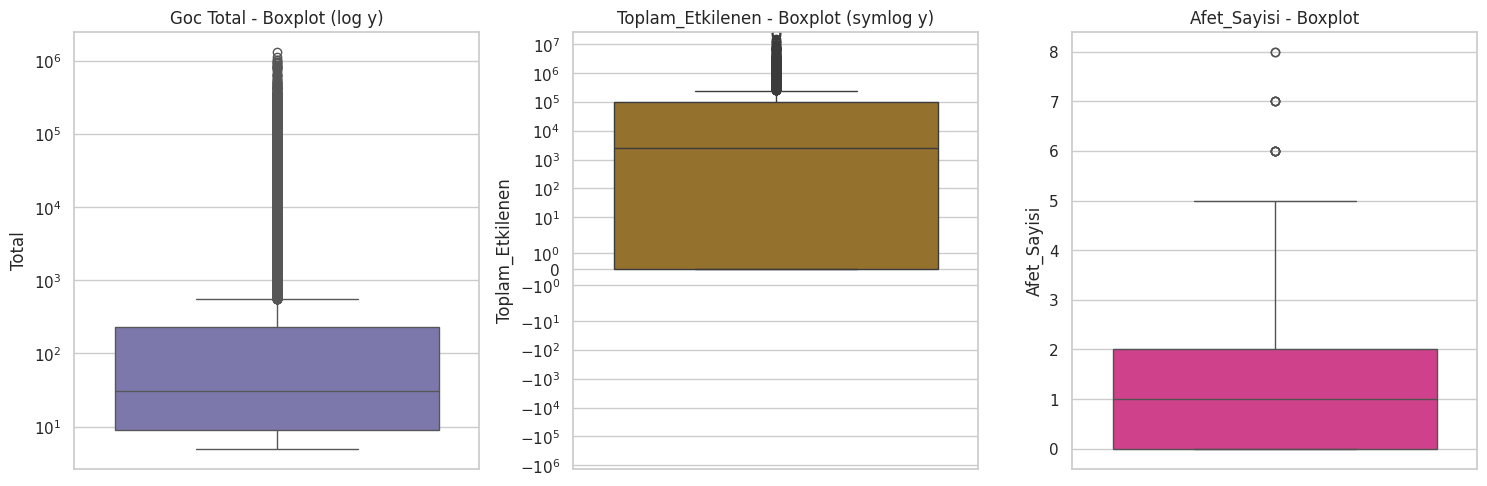

Total: IQR ust siniri=562  | ust sinirin uzerindeki gozlem sayisi=7677 (%17.8)
Toplam_Etkilenen: IQR ust siniri=250,000  | ust sinirin uzerindeki gozlem sayisi=208 (%17.5)
Toplam_Olum: IQR ust siniri=37  | ust sinirin uzerindeki gozlem sayisi=174 (%14.6)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=goc['Total'], ax=axes[0], color='#7570b3'); axes[0].set_yscale('log')
axes[0].set_title('Goc Total - Boxplot (log y)')

sns.boxplot(y=iklim['Toplam_Etkilenen'], ax=axes[1], color='#a6761d')
axes[1].set_yscale('symlog')
axes[1].set_title('Toplam_Etkilenen - Boxplot (symlog y)')

sns.boxplot(y=iklim['Afet_Sayisi'], ax=axes[2], color='#e7298a')
axes[2].set_title('Afet_Sayisi - Boxplot')

plt.tight_layout()
plt.show()

# IQR yontemiyle sayisal ozet
for col, df_ in [('Total', goc), ('Toplam_Etkilenen', iklim), ('Toplam_Olum', iklim)]:
    Q1, Q3 = df_[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    n_out = (df_[col] > upper).sum()
    print(f"{col}: IQR ust siniri={upper:,.0f}  | ust sinirin uzerindeki gozlem sayisi={n_out} (%{n_out/len(df_)*100:.1f})")


> **Bulgu:** Her üç değişkende de klasik IQR yöntemine göre "aykırı" sayılan gözlemlerin oranı yüksek (%15-20 civarı) — bu tipik bir **sağa çarpık, gerçek dünya olay verisi** örüntüsüdür, IQR yöntemi bu tür dağılımlarda çok fazla gözlemi "aykırı" olarak işaretleme eğilimindedir.
> **Değerlendirme (silme YAPILMAMIŞTIR):**
> - **`Total` (göç) uç değerleri** → Bölüm 8.5'te gösterildiği gibi, bunlar Güney Sudan/Sudan gibi ülkelerdeki **gerçek, belgelenmiş çatışma kaynaklı kitlesel göç dalgalarıdır**. Veri hatası değildir, tam tersine bu değerler analizin en kritik bilgisini taşımaktadır.
> - **`Toplam_Etkilenen` uç değerleri** → büyük ölçekli kuraklık/sel gibi felaketlerin (ör. Somali kıtlığı) gerçek etkisini yansıtıyor olabilir; olağanüstü büyüklükte ama gerçek bir olay olması muhtemel.
> - **`Toplam_Olum` uç değerleri** (özellikle Somali) → tek bir çok şiddetli olayla (büyük kıtlık/kuraklık dönemi) ilişkili olabilir; savaş/afet kaynaklı olağanüstü durum kategorisine giriyor.
> **Proje açısından önemi:** Bu değerlerin **silinmesi veya winsorize edilmesi, projenin en önemli bulgularını (kitlesel göç dalgaları, büyük afet etkileri) yok eder.** Olası bir modelleme aşamasında bu uç değerler; log-dönüşüm, sağlam (robust) istatistikler veya ayrı bir "kriz yılı" kategorik değişkeni ile ele alınmalı, doğrudan silinmemelidir.


## 12. Final Insights — Key Findings

Aşağıda, veriyle doğrudan desteklenen **12 temel bulgu** özetlenmiştir (bkz. ilgili bölümler için ayrıntılı sayısal destek).


1. **Veri kalitesi yüksek:** Her iki veri setinde de eksik değer, duplicate kayıt veya ülke isimlendirme tutarsızlığı bulunmamaktadır (Bölüm 2).
2. **Göç akışı 2011'den itibaren keskin ve sürekli artmıştır:** Toplam kayıtlı göç 2001-2010 arasında ~2.8-3.7 milyon bandında yatay seyrederken, 2025'te ~13.5 milyona ulaşmıştır — 2010'a göre ~4.5 kat artış (Bölüm 4).
3. **Ortalama sıcaklık 2001-2025 arasında hafif ama istikrarlı bir artış eğilimindedir** (~24.5°C → ~24.9-25.1°C bandı), ancak bu artış göçteki keskin sıçramayla zamansal olarak örtüşmemektedir (Bölüm 4).
4. **İklim/afet değişkenleri ile göç akışı arasındaki doğrusal korelasyon çok zayıftır** (tüm |r| < 0.15, log-göç ile bile en güçlüsü Avg_Temp için r≈0.29) (Bölüm 5-6).
5. **En güçlü göç veren dört ülke (Güney Sudan, Sudan, Somali, DR Kongo) aynı zamanda uzun süreli iç çatışma tarihine sahip ülkelerdir**; en çok afet yaşayan ülkeler listesiyle örtüşmemektedir (Bölüm 7-8).
6. **Göç akışının büyük kısmı Afrika içi ("South-South") harekettir:** En çok göç kabul eden ülkeler Uganda, Etiyopya, Sudan, Kenya, Çad gibi komşu Afrika ülkeleridir (Bölüm 8.1).
7. **En büyük göç koridoru Güney Sudan → Uganda'dır** (~9.36M kümülatif kişi, 2001-2025), onu Sudan → Çad ve Somali → Kenya izlemektedir (Bölüm 8.3).
8. **Güney Sudan → Uganda koridorunda 2013-2017 arasında dramatik bir sıçrama görülmektedir**, bu da Aralık 2013'te başlayan Güney Sudan iç savaşıyla zamansal olarak örtüşmektedir — veri setinde bulunmayan "çatışma" etkisinin göç verisinde dolaylı izini göstermektedir (Bölüm 8.4).
9. **Afet sıklığı ile afet şiddeti (can kaybı) farklı ülkelerde öne çıkmaktadır:** Somali, toplam afet sayısında ilk 10'da değilken afet kaynaklı ölümde diğer tüm ülkelerin çok üzerindedir (~20.700 ölüm) (Bölüm 7).
10. **Göç, afet ve etkilenen kişi sayısı değişkenleri aşırı sağa çarpıktır** (skewness sırasıyla ~19.6, ~1.7, ~8.1); bu, birkaç ülke-yılın istatistikleri domine ettiğini göstermektedir (Bölüm 3, 11).
11. **Yüksek "aykırı değerler" veri hatası değil, gerçek kriz olaylarıdır** (kitlesel göç dalgaları, büyük afetler) — bu nedenle silinmemiş, olduğu gibi analize dahil edilmiştir (Bölüm 11).
12. **Nüfus verisi eksikliği, kişi başına / oransal karşılaştırmaları imkânsız kılmaktadır** — bu, ülke bazlı bulguların (özellikle büyük/kalabalık ülkelerin öne çıkması) yorumlanmasında dikkate alınması gereken önemli bir sınırlamadır (Bölüm 7, 10).


## 13. Sunum İçin Öneriler (Presentation Recommendations)

Grup sunumunda kullanılabilecek **6 grafik** ve bunlarla ilgili konuşma notları:

| # | Grafik | Neyi gösteriyor? | Neden önemli? | Sunumda ne söylenmeli? |
|---|---|---|---|---|
| 1 | Yıllara göre toplam göç akışı (line chart) | 2001-2025 toplam kayıtlı göç trendi | Projenin ana "hikayesi" — 2011 sonrası dramatik artış | "2010'dan 2025'e göç akışı yaklaşık 4.5 kat arttı; bu artış iklim trendinden çok daha keskin." |
| 2 | Korelasyon heatmap'i | İklim/afet değişkenleri ile göç arasındaki ilişki gücü | Basit "iklim → göç" nedensellik iddiasını sorgulatan kilit bulgu | "İklim değişkenleri göçle güçlü doğrusal ilişki göstermiyor — ilişki var ama karmaşık ve muhtemelen çatışma gibi başka faktörlerle iç içe." |
| 3 | En büyük 15 göç koridoru (barh) | Hangi kaynak→hedef ülke çiftlerinde en çok göç yaşanmış | Somut, isim isim örnekler sunar | "Göçün büyük kısmı komşu ülkeler arasında — Güney Sudan'dan Uganda'ya, Sudan'dan Çad'a." |
| 4 | En büyük 5 koridorun zaman serisi | Güney Sudan → Uganda'daki 2013 sonrası sıçrama | Çatışma-göç ilişkisine dair en çarpıcı görsel kanıt | "Bu sıçrama, 2013'te patlak veren Güney Sudan iç savaşıyla birebir örtüşüyor." |
| 5 | Ülke bazlı afet sayısı vs afet kaynaklı ölüm (iki barh yan yana) | Afet sıklığı ile şiddetinin farklı ülkelerde öne çıktığı | "Çok afet = çok ölüm" varsayımını çürüten ince ama önemli bulgu | "Somali'de afet sayısı ilk 10'da değil ama afet kaynaklı ölüm diğer tüm ülkelerin kat kat üzerinde." |
| 6 | Göç akışı dağılımı (log histogram) + boxplot | Verinin aşırı sağa çarpık yapısı | Metodolojik şeffaflık — neden log/medyan kullanıldığını açıklar | "Veri çok çarpık, birkaç büyük kriz istatistikleri domine ediyor; bu yüzden ortalama yerine medyan ve log ölçek kullandık." |

**En önemli 5 bulgu (kısa, sunulabilir):**
1. Göç akışı 2010-2025 arasında ~4.5 kat arttı.
2. İklim/afet değişkenleri ile göç arasında güçlü doğrusal korelasyon bulunamadı (en yüksek |r| ≈ 0.15-0.29).
3. Göçün büyük kısmı Afrika içi, komşu ülkeler arasında gerçekleşiyor.
4. En büyük göç koridoru (Güney Sudan → Uganda) 2013 iç savaşıyla örtüşen keskin bir sıçrama gösteriyor.
5. Afet sıklığı ile afet şiddeti (ölüm) farklı ülkelerde öne çıkıyor — ikisi birbirinin yerine kullanılamaz.


---
## Yöntemsel Notlar ve Sınırlamalar

- Bu EDA, veri setinde **gerçekten var olan** değişkenlerle sınırlıdır; çatışma, nüfus, bölge gibi görev tanımında geçen ama veride bulunmayan değişkenler için hiçbir varsayım veya tahmini değer üretilmemiştir.
- Tüm korelasyon ve ilişki bulguları **tanımlayıcıdır, nedensel değildir.**
- Aykırı değerler bilinçli olarak **silinmemiş veya dönüştürülmemiştir**; bunlar gerçek kriz olaylarını temsil etmektedir.
- Analiz, kişi başına / nüfusa oranlı göstergeler içermemektedir çünkü veri setinde nüfus bilgisi yoktur.
